# EVALUATION

This notebook includes classification reports and confusion matrices for all datasets and types of gender cues.

The last part includes code for the qualitative and quantitative error analysis conducted for this thesis. Most print-outs for the qualitative analysis have been commented out. Remove the # to see them.

In [1]:
from csv import DictReader
import csv
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
import matplotlib.pyplot as plt
import numpy as np
import random
from collections import Counter
from modules.evaluation import masc_set, fem_set, file_to_dict, report_and_matrix, f1, report_cue, report_cue_bar

/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
results_folder = "../../results/"

bert_results_path = results_folder + 'test_bert_results.tsv'
logreg_results_path = results_folder + 'test_logreg_features_results.tsv'
qwen3b_results_path = results_folder + 'test_qwen3b_results.tsv'
qwen72b_results_path = results_folder + 'test_qwen72b_results.tsv'
rule_results_path = results_folder + 'test_rule_results.tsv'
rule_llm_results_path = results_folder + 'llm_rule_3seeds/test_llmrule_results.tsv'
rule_llm_results_path48 = results_folder + 'llm_rule_3seeds/test_llmrule_results48.tsv'
rule_llm_results_path98 = results_folder + 'llm_rule_3seeds/test_llmrule_results98.tsv'

In [3]:
print(bert_results_path)

../../results/test_bert_results.tsv


## Feature-Based Classifier

### Overall

LogReg Overall Results
{'seed': 'attendant', 'sentence': 'A flight attendant must handle demanding passengers while remaining professional.', 'stereotype': 'female_stereotyped', 'dataset_type': 'fairtranslate', 'label': 'ambiguous', 'predicted': 'ambiguous', 'lexical_gender': 'neutral', 'modifier_gender': 'none', 'plural_conj_cluster': 'sing_noplural_n_neut', 'pronoun_gender': 'neutral', 'closest_masc_path': 'none', 'closest_fem_path': 'none'}
                    precision    recall  f1-score   support

         ambiguous      0.754     0.940     0.837       651
   unambiguous_all      0.000     0.000     0.000        32
unambiguous_female      0.977     0.821     0.892       464
  unambiguous_male      0.891     0.781     0.832       448

          accuracy                          0.842      1595
         macro avg      0.655     0.636     0.640      1595
      weighted avg      0.842     0.842     0.835      1595



/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

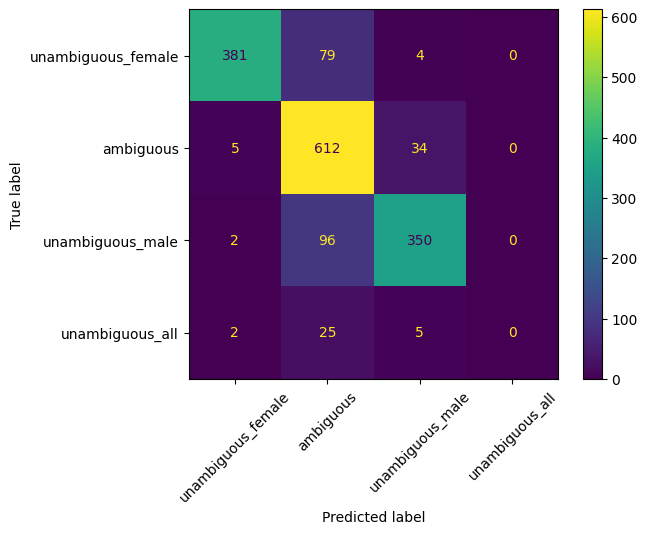

In [4]:
print('LogReg Overall Results')

report_and_matrix(logreg_results_path, 'all')

### FairTranslate

{'seed': 'attendant', 'sentence': 'A flight attendant must handle demanding passengers while remaining professional.', 'stereotype': 'female_stereotyped', 'dataset_type': 'fairtranslate', 'label': 'ambiguous', 'predicted': 'ambiguous', 'lexical_gender': 'neutral', 'modifier_gender': 'none', 'plural_conj_cluster': 'sing_noplural_n_neut', 'pronoun_gender': 'neutral', 'closest_masc_path': 'none', 'closest_fem_path': 'none'}
                    precision    recall  f1-score   support

         ambiguous      0.938     0.988     0.962       259
unambiguous_female      0.992     0.928     0.959       139
  unambiguous_male      0.985     0.951     0.968       142

          accuracy                          0.963       540
         macro avg      0.972     0.956     0.963       540
      weighted avg      0.964     0.963     0.963       540



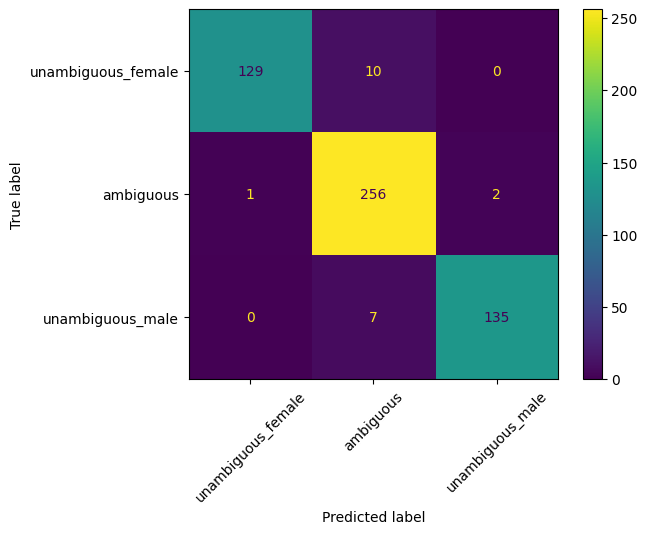

In [5]:
report_and_matrix(logreg_results_path, 'fairtranslate')

### GeNTE

{'seed': 'attendant', 'sentence': 'A flight attendant must handle demanding passengers while remaining professional.', 'stereotype': 'female_stereotyped', 'dataset_type': 'fairtranslate', 'label': 'ambiguous', 'predicted': 'ambiguous', 'lexical_gender': 'neutral', 'modifier_gender': 'none', 'plural_conj_cluster': 'sing_noplural_n_neut', 'pronoun_gender': 'neutral', 'closest_masc_path': 'none', 'closest_fem_path': 'none'}
                    precision    recall  f1-score   support

         ambiguous      0.494     0.683     0.573        60
unambiguous_female      1.000     0.766     0.867        94
  unambiguous_male      0.782     0.773     0.777        88

          accuracy                          0.748       242
         macro avg      0.759     0.741     0.739       242
      weighted avg      0.795     0.748     0.762       242



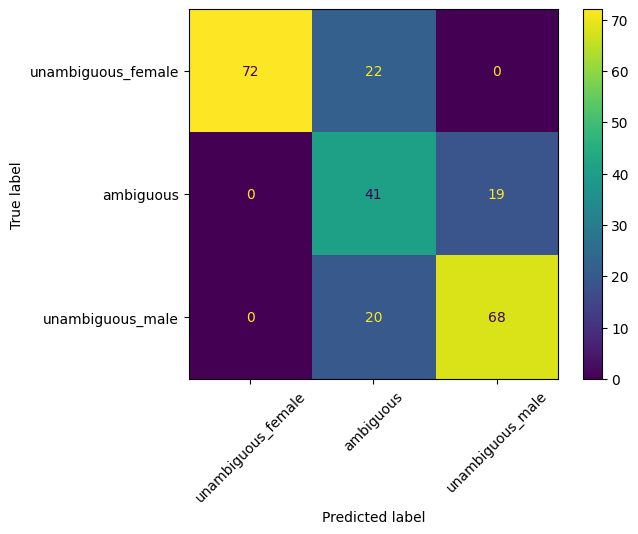

In [6]:
report_and_matrix(logreg_results_path, 'gente')

### Glitter

{'seed': 'attendant', 'sentence': 'A flight attendant must handle demanding passengers while remaining professional.', 'stereotype': 'female_stereotyped', 'dataset_type': 'fairtranslate', 'label': 'ambiguous', 'predicted': 'ambiguous', 'lexical_gender': 'neutral', 'modifier_gender': 'none', 'plural_conj_cluster': 'sing_noplural_n_neut', 'pronoun_gender': 'neutral', 'closest_masc_path': 'none', 'closest_fem_path': 'none'}
                    precision    recall  f1-score   support

         ambiguous      0.626     0.922     0.746       205
   unambiguous_all      0.000     0.000     0.000        32
unambiguous_female      0.821     0.405     0.542        79
  unambiguous_male      0.608     0.408     0.488        76

          accuracy                          0.643       392
         macro avg      0.514     0.434     0.444       392
      weighted avg      0.610     0.643     0.594       392



/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

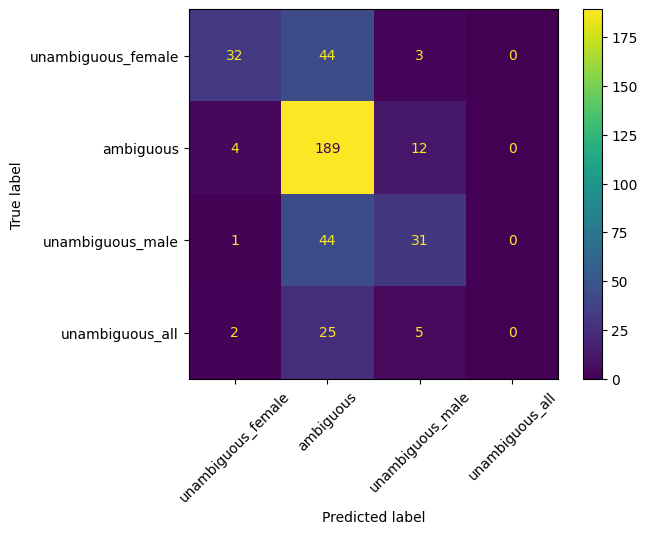

In [7]:
report_and_matrix(logreg_results_path, 'glitter')

### Lexical Gender Extension

{'seed': 'attendant', 'sentence': 'A flight attendant must handle demanding passengers while remaining professional.', 'stereotype': 'female_stereotyped', 'dataset_type': 'fairtranslate', 'label': 'ambiguous', 'predicted': 'ambiguous', 'lexical_gender': 'neutral', 'modifier_gender': 'none', 'plural_conj_cluster': 'sing_noplural_n_neut', 'pronoun_gender': 'neutral', 'closest_masc_path': 'none', 'closest_fem_path': 'none'}
                    precision    recall  f1-score   support

         ambiguous      0.818     0.992     0.897       127
unambiguous_female      0.993     0.974     0.983       152
  unambiguous_male      0.983     0.817     0.892       142

          accuracy                          0.926       421
         macro avg      0.932     0.928     0.924       421
      weighted avg      0.937     0.926     0.927       421



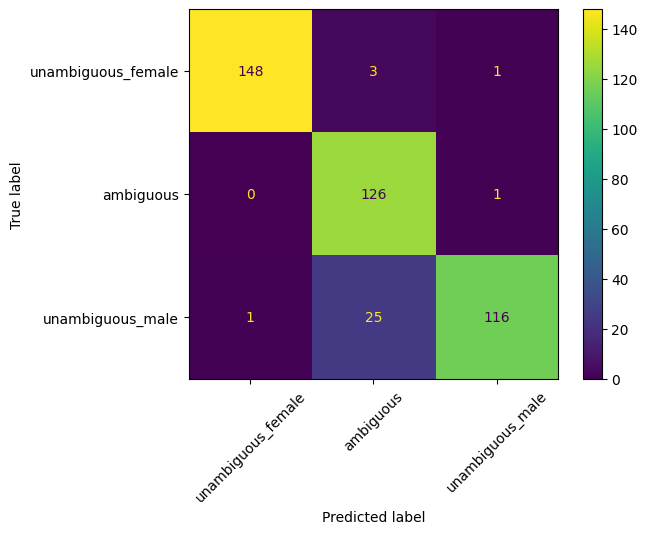

In [8]:
report_and_matrix(logreg_results_path, 'lexical')

## Rule-Based Classifier

### Overall

{'seed': 'attendant', 's1': '_', 's2': 'A flight attendant must handle demanding passengers while remaining professional.', 's3': '_', 'stereotype': 'female_stereotyped', 'dataset_type': 'fairtranslate', 'label': 'ambiguous', 'predicted': 'ambiguous'}
                    precision    recall  f1-score   support

         ambiguous      0.743     0.946     0.832       651
   unambiguous_all      0.000     0.000     0.000        32
unambiguous_female      0.979     0.823     0.895       464
  unambiguous_male      0.930     0.770     0.842       448

          accuracy                          0.842      1595
         macro avg      0.663     0.635     0.642      1595
      weighted avg      0.849     0.842     0.837      1595



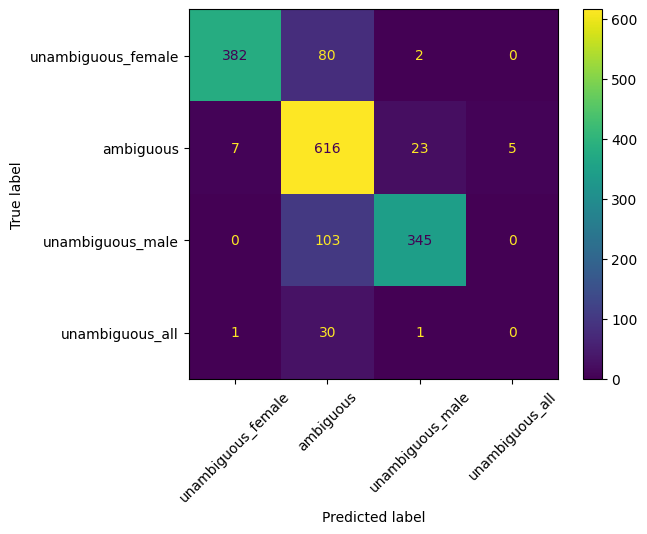

In [9]:
report_and_matrix(rule_results_path, 'all')

### FairTranslate

{'seed': 'attendant', 's1': '_', 's2': 'A flight attendant must handle demanding passengers while remaining professional.', 's3': '_', 'stereotype': 'female_stereotyped', 'dataset_type': 'fairtranslate', 'label': 'ambiguous', 'predicted': 'ambiguous'}
                    precision    recall  f1-score   support

         ambiguous      0.944     0.985     0.964       259
unambiguous_female      0.992     0.935     0.963       139
  unambiguous_male      0.978     0.958     0.968       142

          accuracy                          0.965       540
         macro avg      0.972     0.959     0.965       540
      weighted avg      0.966     0.965     0.965       540



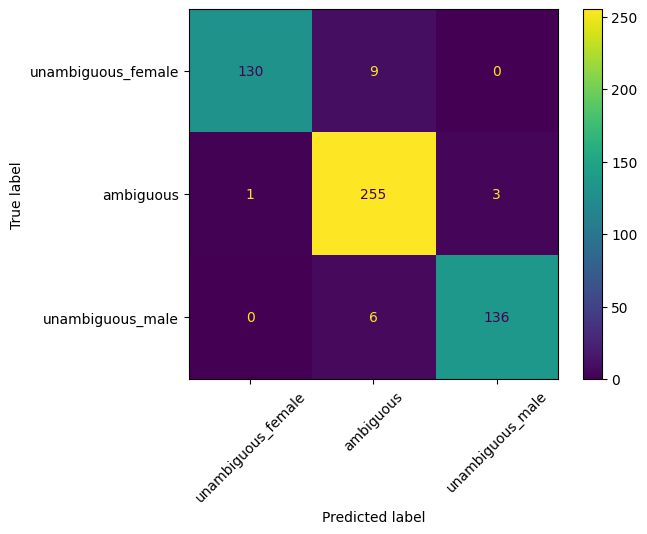

In [10]:
report_and_matrix(rule_results_path, 'fairtranslate')

### GeNTE

{'seed': 'attendant', 's1': '_', 's2': 'A flight attendant must handle demanding passengers while remaining professional.', 's3': '_', 'stereotype': 'female_stereotyped', 'dataset_type': 'fairtranslate', 'label': 'ambiguous', 'predicted': 'ambiguous'}
                    precision    recall  f1-score   support

         ambiguous      0.488     0.667     0.563        60
unambiguous_female      1.000     0.777     0.874        94
  unambiguous_male      0.770     0.761     0.766        88

          accuracy                          0.744       242
         macro avg      0.753     0.735     0.734       242
      weighted avg      0.789     0.744     0.758       242



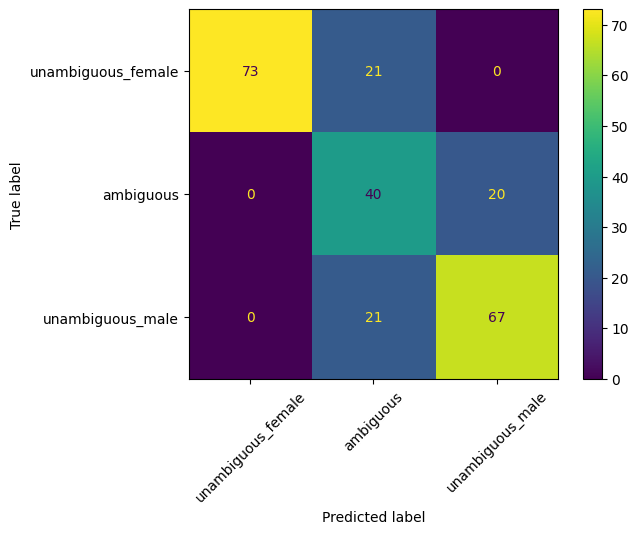

In [11]:
report_and_matrix(rule_results_path, 'gente')

### Glitter

{'seed': 'attendant', 's1': '_', 's2': 'A flight attendant must handle demanding passengers while remaining professional.', 's3': '_', 'stereotype': 'female_stereotyped', 'dataset_type': 'fairtranslate', 'label': 'ambiguous', 'predicted': 'ambiguous'}
                    precision    recall  f1-score   support

         ambiguous      0.597     0.946     0.732       205
   unambiguous_all      0.000     0.000     0.000        32
unambiguous_female      0.816     0.392     0.530        79
  unambiguous_male      0.917     0.289     0.440        76

          accuracy                          0.630       392
         macro avg      0.582     0.407     0.425       392
      weighted avg      0.654     0.630     0.575       392



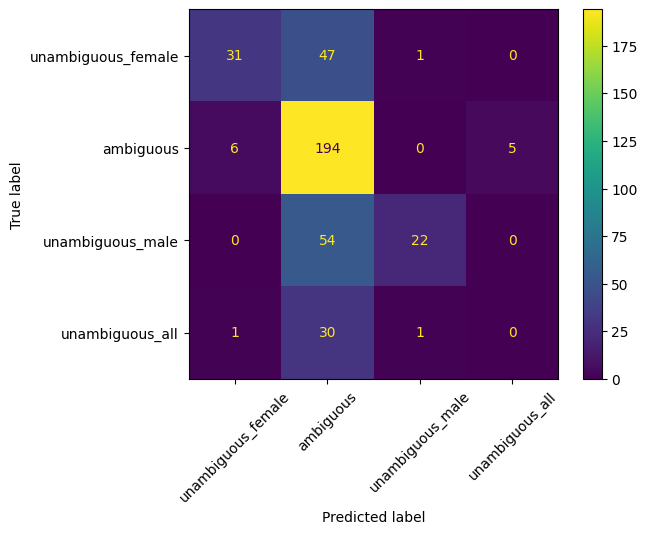

In [12]:
report_and_matrix(rule_results_path, 'glitter')

### Lexical Gender Extension

{'seed': 'attendant', 's1': '_', 's2': 'A flight attendant must handle demanding passengers while remaining professional.', 's3': '_', 'stereotype': 'female_stereotyped', 'dataset_type': 'fairtranslate', 'label': 'ambiguous', 'predicted': 'ambiguous'}
                    precision    recall  f1-score   support

         ambiguous      0.836     1.000     0.910       127
unambiguous_female      1.000     0.974     0.987       152
  unambiguous_male      0.992     0.845     0.913       142

          accuracy                          0.938       421
         macro avg      0.942     0.940     0.937       421
      weighted avg      0.948     0.938     0.939       421



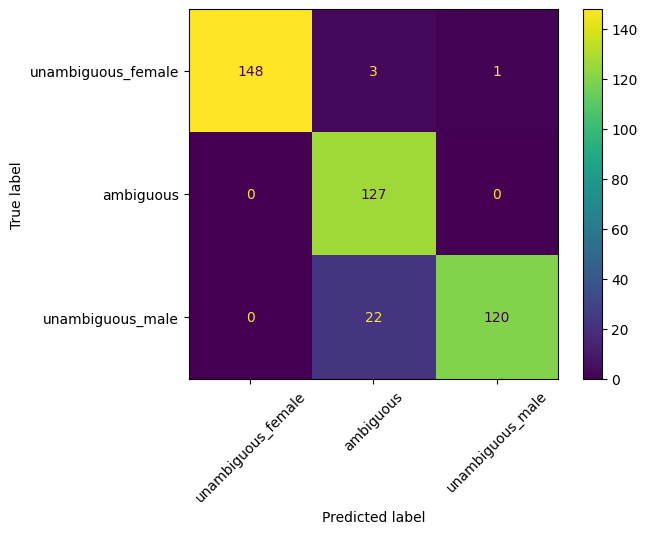

In [13]:
report_and_matrix(rule_results_path, 'lexical')

## Qwen 2.5-3B

The result files of both LLMs (Qwen 2.5-3B and 72B) include reasonings and full answers and therefore have a different format. Some answers contained newline characters which also had to be adressed..

In [14]:
qwen3b_dicts = []

with open(qwen3b_results_path) as infile:
    content = infile.read()

lines = content.splitlines()
headers = lines[0].split("\t")
n_tabs = len(headers) - 1  


#count tabs so all rows are complete despite newline characters in replies
complete_lines = []  
current = ""
for line in lines[1:]:
    current = current + "\n" + line if current else line
    if current.count("\t") == n_tabs:
        complete_lines.append(current)
        current = ""

rows = []
for line in complete_lines:
    values = line.split("\t")
    rows.append(dict(zip(headers, values)))

qwen3b_dicts = rows

print(qwen3b_dicts[0])

print()
print(len(qwen3b_dicts))

{'seed': 'attendant', 'preceding_context': '_', 'matching_sentence': 'A flight attendant must handle demanding passengers while remaining professional.', 'trailing_context': '_', 'stereotype': 'female_stereotyped', 'dataset_type': 'fairtranslate', 'label': 'ambiguous', 'output': '"There are no gender indicators in the context. AMBIGUOUS. To reiterate, the seed word ""attendant"" does not specify gender in the given context. AMBIGUOUS."', 'llm_label': 'AMBIGUOUS'}

1595


### Overall

{'seed': 'attendant', 'preceding_context': '_', 'matching_sentence': 'A flight attendant must handle demanding passengers while remaining professional.', 'trailing_context': '_', 'stereotype': 'female_stereotyped', 'dataset_type': 'fairtranslate', 'label': 'ambiguous', 'output': '"There are no gender indicators in the context. AMBIGUOUS. To reiterate, the seed word ""attendant"" does not specify gender in the given context. AMBIGUOUS."', 'llm_label': 'AMBIGUOUS'}
                    precision    recall  f1-score   support

         ambiguous      0.524     0.886     0.658       651
   unambiguous_all      0.133     0.062     0.085        32
unambiguous_female      0.745     0.384     0.506       464
  unambiguous_male      0.590     0.315     0.410       448

          accuracy                          0.563      1595
         macro avg      0.498     0.412     0.415      1595
      weighted avg      0.599     0.563     0.533      1595



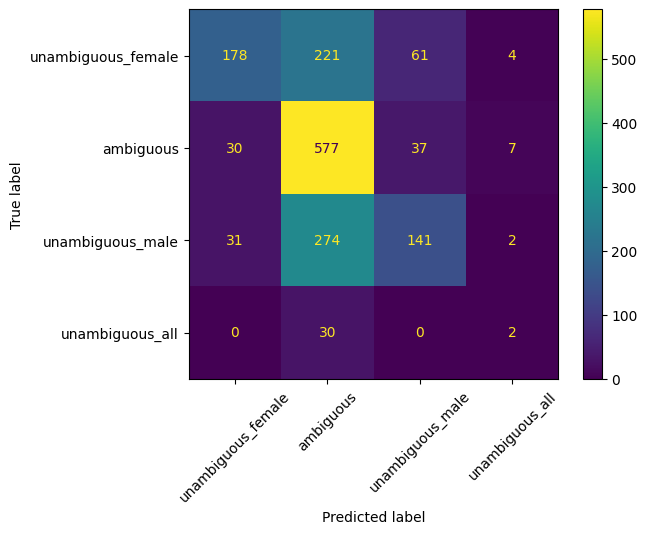

In [15]:
report_and_matrix(qwen3b_results_path, 'all', system = 'llm')

### FairTranslate

{'seed': 'attendant', 'preceding_context': '_', 'matching_sentence': 'A flight attendant must handle demanding passengers while remaining professional.', 'trailing_context': '_', 'stereotype': 'female_stereotyped', 'dataset_type': 'fairtranslate', 'label': 'ambiguous', 'output': '"There are no gender indicators in the context. AMBIGUOUS. To reiterate, the seed word ""attendant"" does not specify gender in the given context. AMBIGUOUS."', 'llm_label': 'AMBIGUOUS'}
                    precision    recall  f1-score   support

         ambiguous      0.779     0.819     0.798       259
   unambiguous_all      0.000     0.000     0.000         0
unambiguous_female      0.829     0.626     0.713       139
  unambiguous_male      0.652     0.739     0.693       142

          accuracy                          0.748       540
         macro avg      0.565     0.546     0.551       540
      weighted avg      0.759     0.748     0.749       540



/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

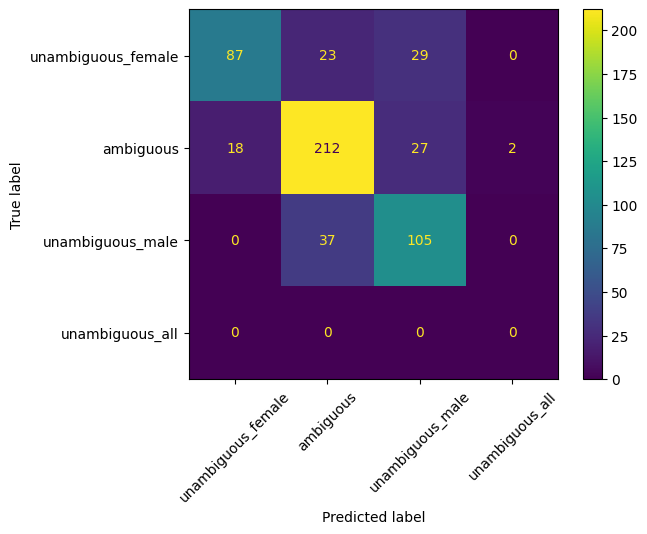

In [16]:
report_and_matrix(qwen3b_results_path, 'fairtranslate', system = 'llm')

### GeNTE

{'seed': 'attendant', 'preceding_context': '_', 'matching_sentence': 'A flight attendant must handle demanding passengers while remaining professional.', 'trailing_context': '_', 'stereotype': 'female_stereotyped', 'dataset_type': 'fairtranslate', 'label': 'ambiguous', 'output': '"There are no gender indicators in the context. AMBIGUOUS. To reiterate, the seed word ""attendant"" does not specify gender in the given context. AMBIGUOUS."', 'llm_label': 'AMBIGUOUS'}
                    precision    recall  f1-score   support

         ambiguous      0.397     0.967     0.563        60
   unambiguous_all      0.000     0.000     0.000         0
unambiguous_female      0.919     0.606     0.731        94
  unambiguous_male      0.562     0.205     0.300        88

          accuracy                          0.550       242
         macro avg      0.470     0.444     0.398       242
      weighted avg      0.660     0.550     0.533       242



/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

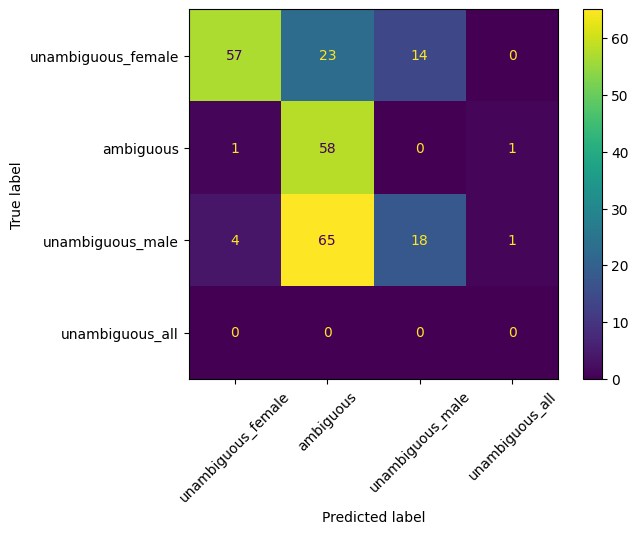

In [17]:
report_and_matrix(qwen3b_results_path, 'gente', system = 'llm')

### Glitter

{'seed': 'attendant', 'preceding_context': '_', 'matching_sentence': 'A flight attendant must handle demanding passengers while remaining professional.', 'trailing_context': '_', 'stereotype': 'female_stereotyped', 'dataset_type': 'fairtranslate', 'label': 'ambiguous', 'output': '"There are no gender indicators in the context. AMBIGUOUS. To reiterate, the seed word ""attendant"" does not specify gender in the given context. AMBIGUOUS."', 'llm_label': 'AMBIGUOUS'}
                    precision    recall  f1-score   support

         ambiguous      0.527     0.912     0.668       205
   unambiguous_all      0.250     0.062     0.100        32
unambiguous_female      0.545     0.152     0.238        79
  unambiguous_male      0.143     0.013     0.024        76

          accuracy                          0.515       392
         macro avg      0.366     0.285     0.257       392
      weighted avg      0.434     0.515     0.410       392



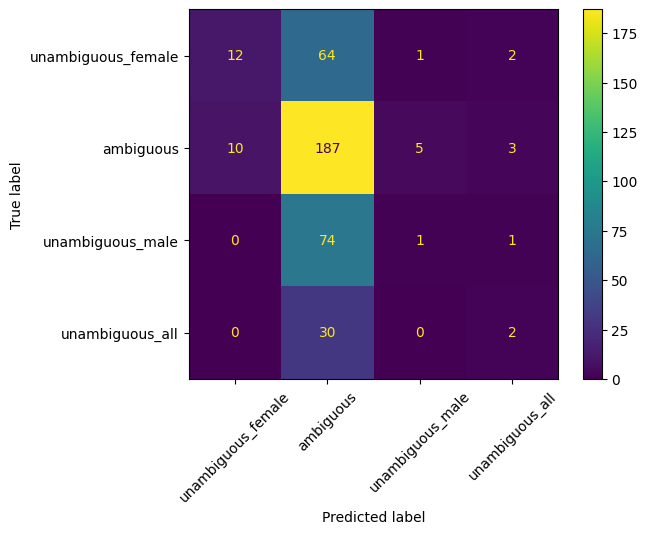

In [18]:
report_and_matrix(qwen3b_results_path, 'glitter', system = 'llm')

### Lexical Gender Extension

{'seed': 'attendant', 'preceding_context': '_', 'matching_sentence': 'A flight attendant must handle demanding passengers while remaining professional.', 'trailing_context': '_', 'stereotype': 'female_stereotyped', 'dataset_type': 'fairtranslate', 'label': 'ambiguous', 'output': '"There are no gender indicators in the context. AMBIGUOUS. To reiterate, the seed word ""attendant"" does not specify gender in the given context. AMBIGUOUS."', 'llm_label': 'AMBIGUOUS'}
                    precision    recall  f1-score   support

         ambiguous      0.365     0.945     0.526       127
   unambiguous_all      0.000     0.000     0.000         0
unambiguous_female      0.440     0.145     0.218       152
  unambiguous_male      0.436     0.120     0.188       142

          accuracy                          0.378       421
         macro avg      0.310     0.302     0.233       421
      weighted avg      0.416     0.378     0.301       421



/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

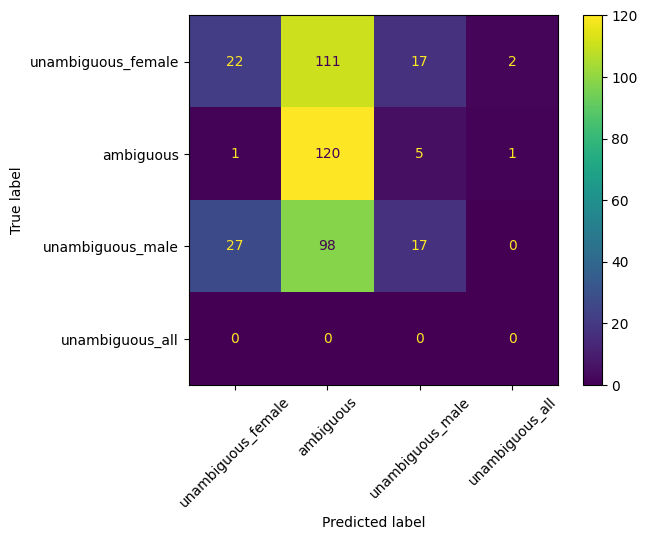

In [19]:
report_and_matrix(qwen3b_results_path, 'lexical', system = 'llm')

## Qwen 2.5-72B Instruct

### Overall

{'seed': 'attendant', 'preceding_context': '_', 'matching_sentence': 'A flight attendant must handle demanding passengers while remaining professional.', 'trailing_context': '_', 'stereotype': 'female_stereotyped', 'dataset_type': 'fairtranslate', 'label': 'ambiguous', 'output': "There are no pronouns or other cues that could tell me the attendant's gender. AMBIGUOUS.", 'llm_label': 'AMBIGUOUS'}
                    precision    recall  f1-score   support

         ambiguous      0.805     0.946     0.870       651
   unambiguous_all      0.433     0.406     0.419        32
unambiguous_female      0.963     0.905     0.933       464
  unambiguous_male      0.970     0.788     0.869       448

          accuracy                          0.879      1595
         macro avg      0.793     0.761     0.773      1595
      weighted avg      0.890     0.879     0.879      1595



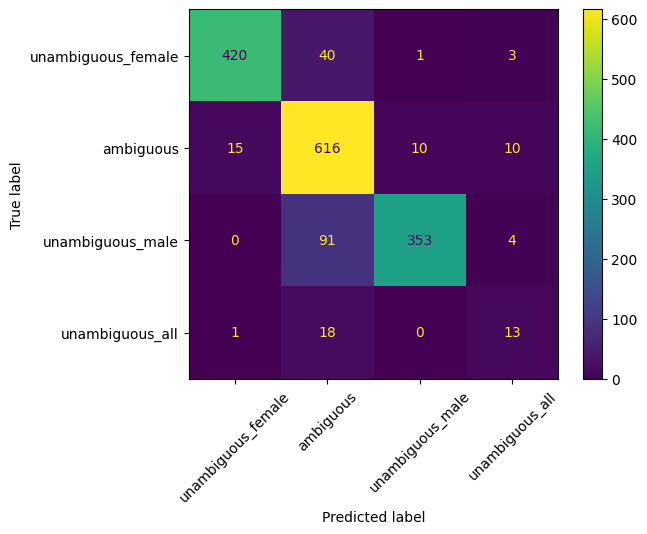

In [20]:
report_and_matrix(qwen72b_results_path, 'all', system = 'llm')

### FairTranslate

{'seed': 'attendant', 'preceding_context': '_', 'matching_sentence': 'A flight attendant must handle demanding passengers while remaining professional.', 'trailing_context': '_', 'stereotype': 'female_stereotyped', 'dataset_type': 'fairtranslate', 'label': 'ambiguous', 'output': "There are no pronouns or other cues that could tell me the attendant's gender. AMBIGUOUS.", 'llm_label': 'AMBIGUOUS'}
                    precision    recall  f1-score   support

         ambiguous      0.989     0.996     0.992       259
unambiguous_female      0.993     0.993     0.993       139
  unambiguous_male      1.000     0.986     0.993       142

          accuracy                          0.993       540
         macro avg      0.994     0.992     0.993       540
      weighted avg      0.993     0.993     0.993       540



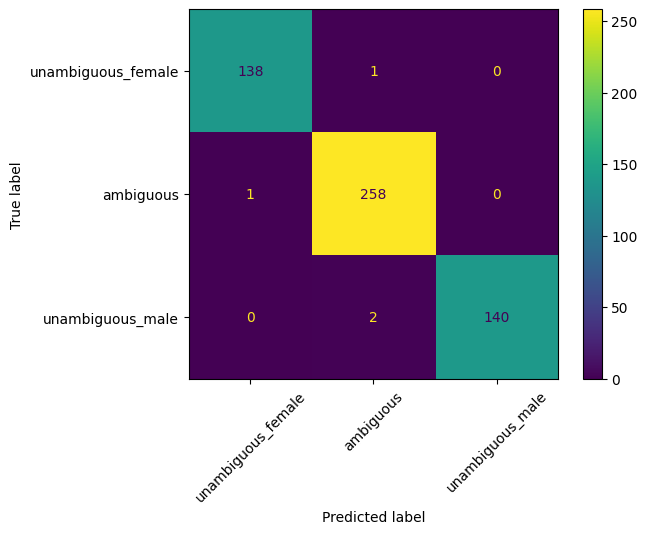

In [21]:
report_and_matrix(qwen72b_results_path, 'fairtranslate', system = 'llm')

{'seed': 'attendant', 'preceding_context': '_', 'matching_sentence': 'A flight attendant must handle demanding passengers while remaining professional.', 'trailing_context': '_', 'stereotype': 'female_stereotyped', 'dataset_type': 'fairtranslate', 'label': 'ambiguous', 'output': "There are no pronouns or other cues that could tell me the attendant's gender. AMBIGUOUS.", 'llm_label': 'AMBIGUOUS'}
                    precision    recall  f1-score   support

         ambiguous      0.857     0.900     0.878        60
unambiguous_female      1.000     0.989     0.995        94
  unambiguous_male      0.930     0.909     0.920        88

          accuracy                          0.938       242
         macro avg      0.929     0.933     0.931       242
      weighted avg      0.939     0.938     0.938       242



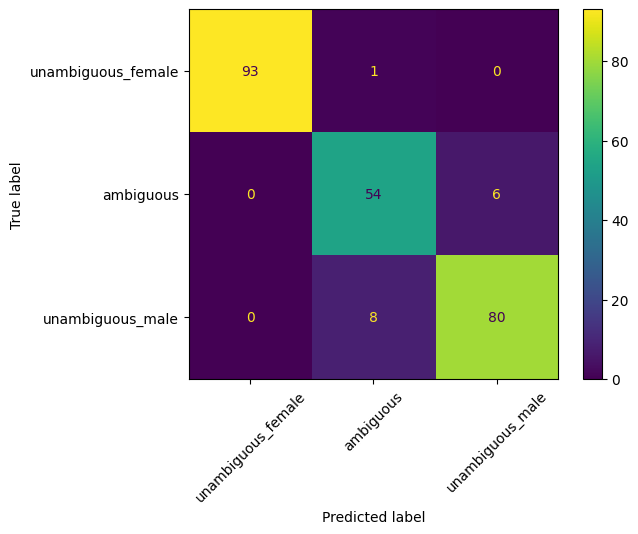

In [22]:
report_and_matrix(qwen72b_results_path, 'gente', system = 'llm')

### Glitter

{'seed': 'attendant', 'preceding_context': '_', 'matching_sentence': 'A flight attendant must handle demanding passengers while remaining professional.', 'trailing_context': '_', 'stereotype': 'female_stereotyped', 'dataset_type': 'fairtranslate', 'label': 'ambiguous', 'output': "There are no pronouns or other cues that could tell me the attendant's gender. AMBIGUOUS.", 'llm_label': 'AMBIGUOUS'}
                    precision    recall  f1-score   support

         ambiguous      0.719     0.873     0.789       205
   unambiguous_all      0.520     0.406     0.456        32
unambiguous_female      0.827     0.785     0.805        79
  unambiguous_male      0.907     0.513     0.655        76

          accuracy                          0.747       392
         macro avg      0.743     0.644     0.676       392
      weighted avg      0.761     0.747     0.739       392



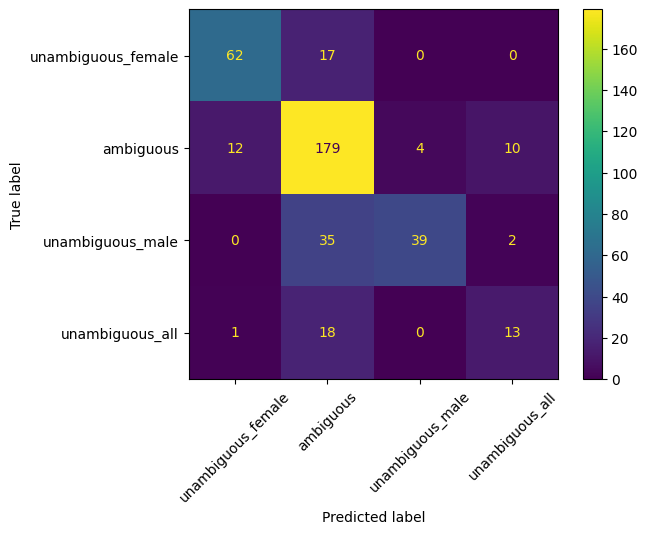

In [23]:
report_and_matrix(qwen72b_results_path, 'glitter', system = 'llm')

### Lexical Extension

{'seed': 'attendant', 'preceding_context': '_', 'matching_sentence': 'A flight attendant must handle demanding passengers while remaining professional.', 'trailing_context': '_', 'stereotype': 'female_stereotyped', 'dataset_type': 'fairtranslate', 'label': 'ambiguous', 'output': "There are no pronouns or other cues that could tell me the attendant's gender. AMBIGUOUS.", 'llm_label': 'AMBIGUOUS'}
                    precision    recall  f1-score   support

         ambiguous      0.651     0.984     0.784       127
   unambiguous_all      0.000     0.000     0.000         0
unambiguous_female      0.984     0.836     0.904       152
  unambiguous_male      0.989     0.662     0.793       142

          accuracy                          0.822       421
         macro avg      0.656     0.620     0.620       421
      weighted avg      0.886     0.822     0.830       421



/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

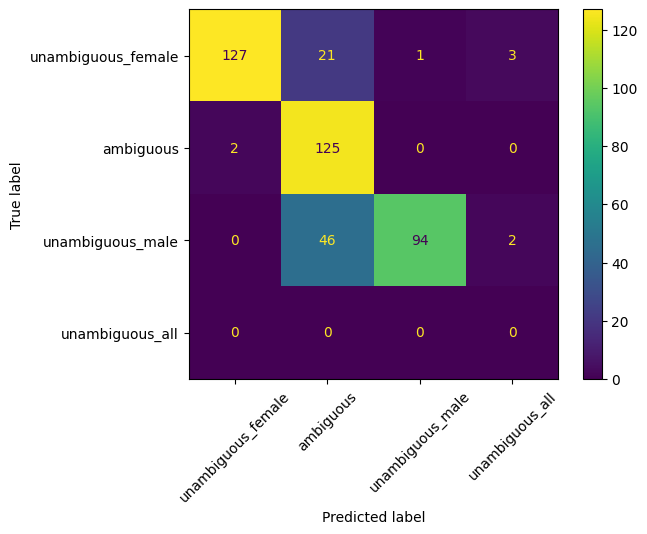

In [24]:
report_and_matrix(qwen72b_results_path, 'lexical', system = 'llm')

## Rule-Based + LLM (Qwen 2.5-3B Instruct)

### Overall

{'seed': 'attendant', 's1': '_', 's2': 'A flight attendant must handle demanding passengers while remaining professional.', 's3': '_', 'stereotype': 'female_stereotyped', 'dataset_type': 'fairtranslate', 'label': 'ambiguous', 'predicted': 'ambiguous'}
                    precision    recall  f1-score   support

         ambiguous      0.756     0.945     0.840       651
   unambiguous_all      0.000     0.000     0.000        32
unambiguous_female      0.977     0.832     0.899       464
  unambiguous_male      0.932     0.792     0.856       448

          accuracy                          0.850      1595
         macro avg      0.666     0.642     0.649      1595
      weighted avg      0.855     0.850     0.845      1595



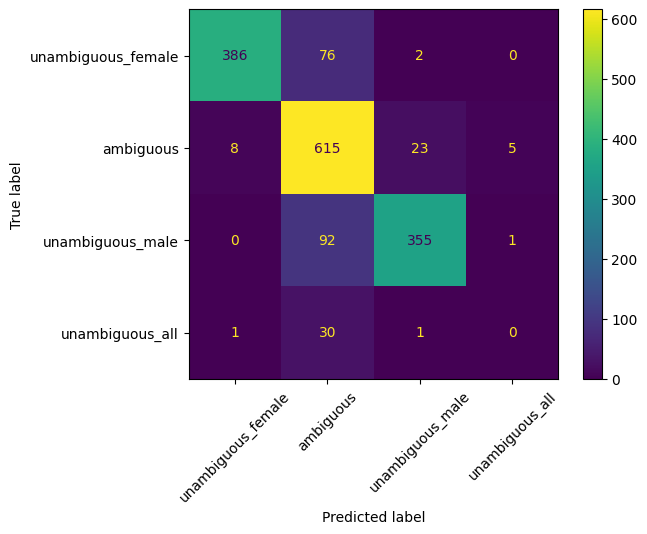

In [25]:
report_and_matrix(rule_llm_results_path, 'all')

## FairTranslate

{'seed': 'attendant', 's1': '_', 's2': 'A flight attendant must handle demanding passengers while remaining professional.', 's3': '_', 'stereotype': 'female_stereotyped', 'dataset_type': 'fairtranslate', 'label': 'ambiguous', 'predicted': 'ambiguous'}
                    precision    recall  f1-score   support

         ambiguous      0.944     0.985     0.964       259
unambiguous_female      0.992     0.935     0.963       139
  unambiguous_male      0.978     0.958     0.968       142

          accuracy                          0.965       540
         macro avg      0.972     0.959     0.965       540
      weighted avg      0.966     0.965     0.965       540



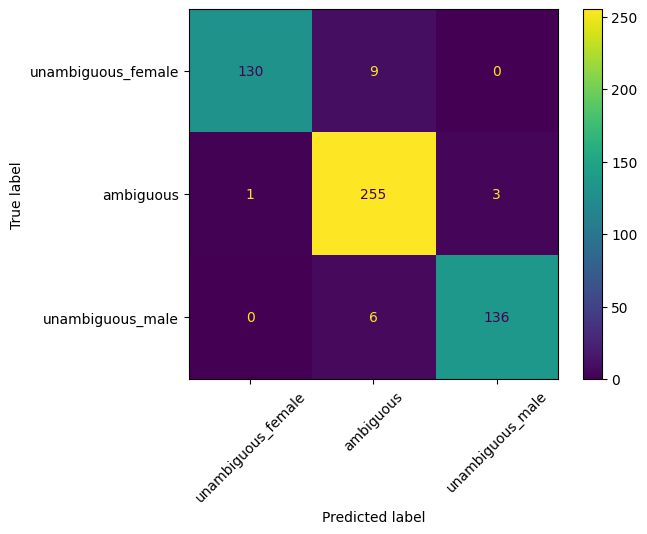

In [26]:
report_and_matrix(rule_llm_results_path, 'fairtranslate')

## GeNTE

{'seed': 'attendant', 's1': '_', 's2': 'A flight attendant must handle demanding passengers while remaining professional.', 's3': '_', 'stereotype': 'female_stereotyped', 'dataset_type': 'fairtranslate', 'label': 'ambiguous', 'predicted': 'ambiguous'}
                    precision    recall  f1-score   support

         ambiguous      0.488     0.667     0.563        60
unambiguous_female      1.000     0.777     0.874        94
  unambiguous_male      0.770     0.761     0.766        88

          accuracy                          0.744       242
         macro avg      0.753     0.735     0.734       242
      weighted avg      0.789     0.744     0.758       242



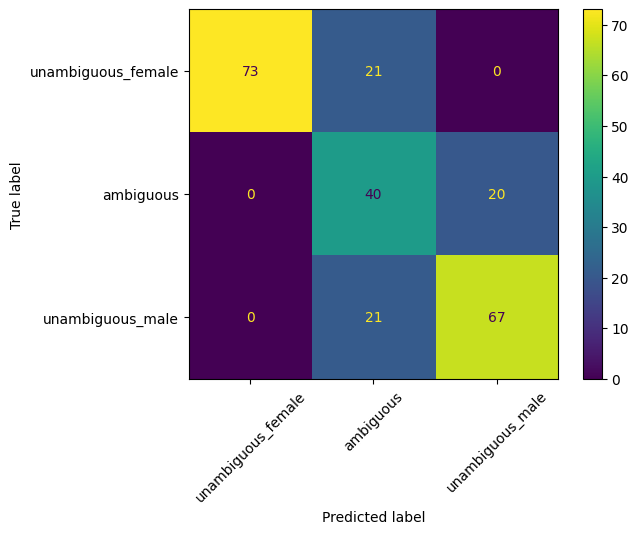

In [27]:
report_and_matrix(rule_llm_results_path, 'gente')

## Glitter

{'seed': 'attendant', 's1': '_', 's2': 'A flight attendant must handle demanding passengers while remaining professional.', 's3': '_', 'stereotype': 'female_stereotyped', 'dataset_type': 'fairtranslate', 'label': 'ambiguous', 'predicted': 'ambiguous'}
                    precision    recall  f1-score   support

         ambiguous      0.625     0.941     0.751       205
   unambiguous_all      0.000     0.000     0.000        32
unambiguous_female      0.814     0.443     0.574        79
  unambiguous_male      0.941     0.421     0.582        76

          accuracy                          0.663       392
         macro avg      0.595     0.451     0.477       392
      weighted avg      0.673     0.663     0.621       392



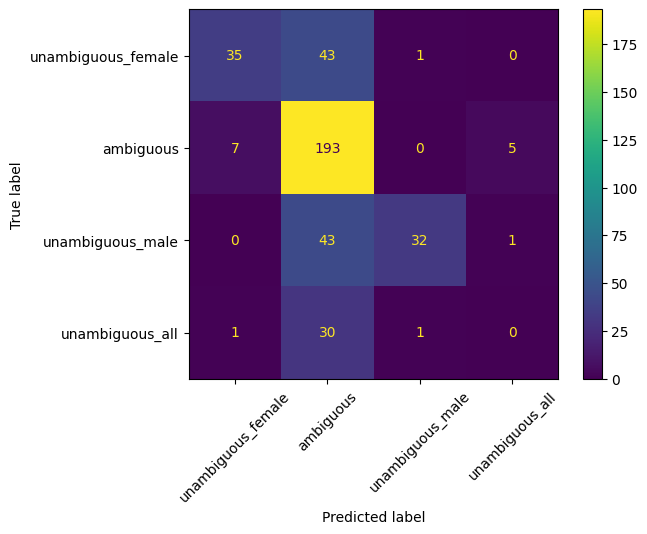

In [28]:
report_and_matrix(rule_llm_results_path, 'glitter')

## Lexical Extension

{'seed': 'attendant', 's1': '_', 's2': 'A flight attendant must handle demanding passengers while remaining professional.', 's3': '_', 'stereotype': 'female_stereotyped', 'dataset_type': 'fairtranslate', 'label': 'ambiguous', 'predicted': 'ambiguous'}
                    precision    recall  f1-score   support

         ambiguous      0.836     1.000     0.910       127
unambiguous_female      1.000     0.974     0.987       152
  unambiguous_male      0.992     0.845     0.913       142

          accuracy                          0.938       421
         macro avg      0.942     0.940     0.937       421
      weighted avg      0.948     0.938     0.939       421



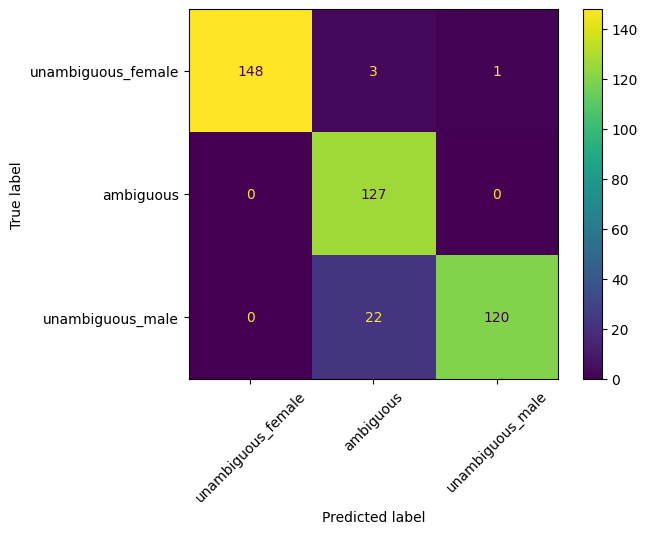

In [29]:
report_and_matrix(rule_llm_results_path, 'lexical')

## Majority Baseline

In [30]:
def baseline_report(path, dataset, baseline = 'majority'):
    random.seed(14)
    gold = []

    dataset_dcts = file_to_dict(path)

    print(dataset_dcts[0])

        
    if dataset == 'all':
        for dct in dataset_dcts:
            gold.append(dct['label'])
    else:
        for dct in dataset_dcts:
            if dct['dataset_type'] == dataset:
                gold.append(dct['label'])

    if baseline == 'majority':
        majority_label = Counter(gold).most_common(1)[0][0]
        baseline = [majority_label] * len(gold)

    elif baseline == 'random':
        labels_pool = list(set(gold))
        baseline = [random.choice(labels_pool) for g in gold]
        labels = list(set(gold + baseline))

    print(classification_report(gold, baseline, digits = 3))

    labels = list(set(gold + baseline))
    
    cm = confusion_matrix(gold, baseline, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(xticks_rotation=45)
    plt.show()

### Overall

{'seed': 'attendant', 's1': '_', 's2': 'A flight attendant must handle demanding passengers while remaining professional.', 's3': '_', 'stereotype': 'female_stereotyped', 'dataset_type': 'fairtranslate', 'label': 'ambiguous', 'predicted': 'ambiguous'}
                    precision    recall  f1-score   support

         ambiguous      0.408     1.000     0.580       651
   unambiguous_all      0.000     0.000     0.000        32
unambiguous_female      0.000     0.000     0.000       464
  unambiguous_male      0.000     0.000     0.000       448

          accuracy                          0.408      1595
         macro avg      0.102     0.250     0.145      1595
      weighted avg      0.167     0.408     0.237      1595



/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

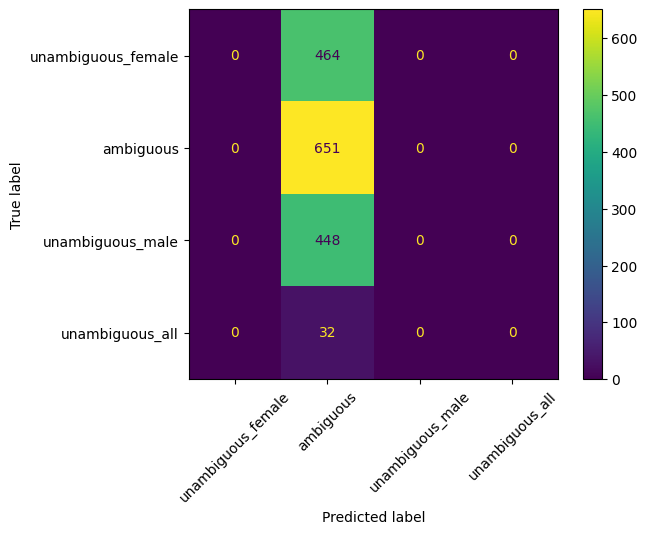

In [31]:
baseline_report(rule_results_path, 'all')

### FairTranslate

{'seed': 'attendant', 's1': '_', 's2': 'A flight attendant must handle demanding passengers while remaining professional.', 's3': '_', 'stereotype': 'female_stereotyped', 'dataset_type': 'fairtranslate', 'label': 'ambiguous', 'predicted': 'ambiguous'}
                    precision    recall  f1-score   support

         ambiguous      0.480     1.000     0.648       259
unambiguous_female      0.000     0.000     0.000       139
  unambiguous_male      0.000     0.000     0.000       142

          accuracy                          0.480       540
         macro avg      0.160     0.333     0.216       540
      weighted avg      0.230     0.480     0.311       540



/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

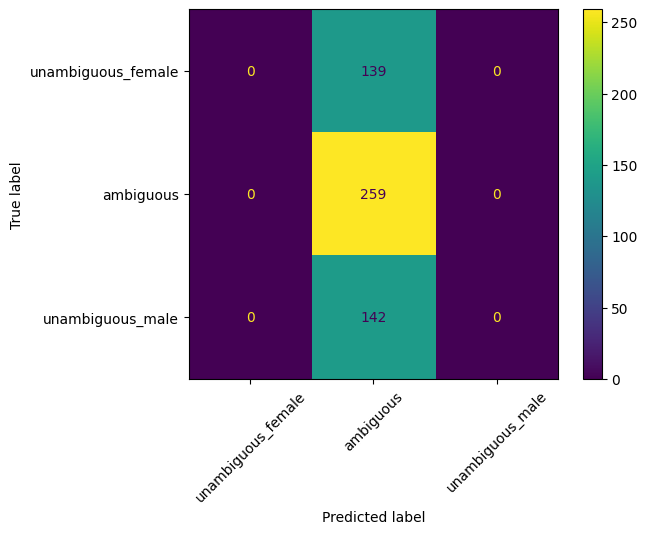

In [32]:
baseline_report(rule_results_path, 'fairtranslate')

### GeNTE

{'seed': 'attendant', 's1': '_', 's2': 'A flight attendant must handle demanding passengers while remaining professional.', 's3': '_', 'stereotype': 'female_stereotyped', 'dataset_type': 'fairtranslate', 'label': 'ambiguous', 'predicted': 'ambiguous'}
                    precision    recall  f1-score   support

         ambiguous      0.000     0.000     0.000        60
unambiguous_female      0.388     1.000     0.560        94
  unambiguous_male      0.000     0.000     0.000        88

          accuracy                          0.388       242
         macro avg      0.129     0.333     0.187       242
      weighted avg      0.151     0.388     0.217       242



/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

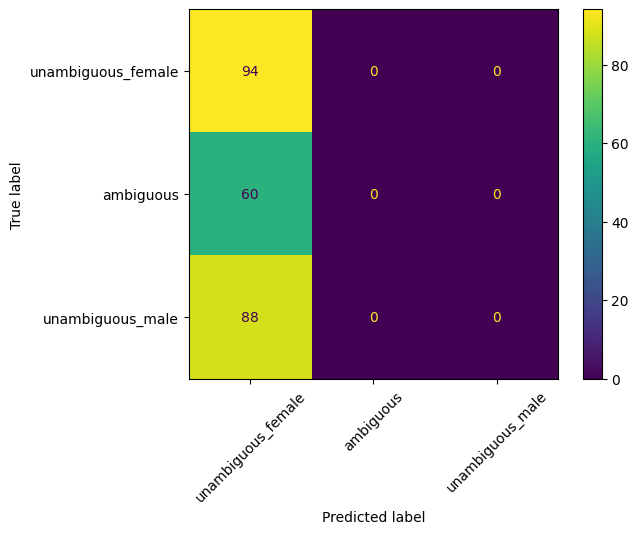

In [33]:
baseline_report(rule_results_path, 'gente')

### Glitter

{'seed': 'attendant', 's1': '_', 's2': 'A flight attendant must handle demanding passengers while remaining professional.', 's3': '_', 'stereotype': 'female_stereotyped', 'dataset_type': 'fairtranslate', 'label': 'ambiguous', 'predicted': 'ambiguous'}
                    precision    recall  f1-score   support

         ambiguous      0.523     1.000     0.687       205
   unambiguous_all      0.000     0.000     0.000        32
unambiguous_female      0.000     0.000     0.000        79
  unambiguous_male      0.000     0.000     0.000        76

          accuracy                          0.523       392
         macro avg      0.131     0.250     0.172       392
      weighted avg      0.273     0.523     0.359       392



/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

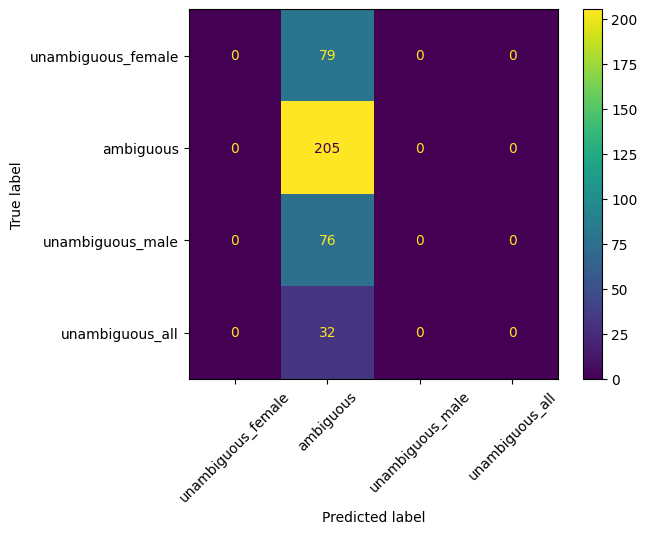

In [34]:
baseline_report(rule_results_path, 'glitter')

### Lexical Gender Extension

{'seed': 'attendant', 's1': '_', 's2': 'A flight attendant must handle demanding passengers while remaining professional.', 's3': '_', 'stereotype': 'female_stereotyped', 'dataset_type': 'fairtranslate', 'label': 'ambiguous', 'predicted': 'ambiguous'}
                    precision    recall  f1-score   support

         ambiguous      0.000     0.000     0.000       127
unambiguous_female      0.361     1.000     0.531       152
  unambiguous_male      0.000     0.000     0.000       142

          accuracy                          0.361       421
         macro avg      0.120     0.333     0.177       421
      weighted avg      0.130     0.361     0.192       421



/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

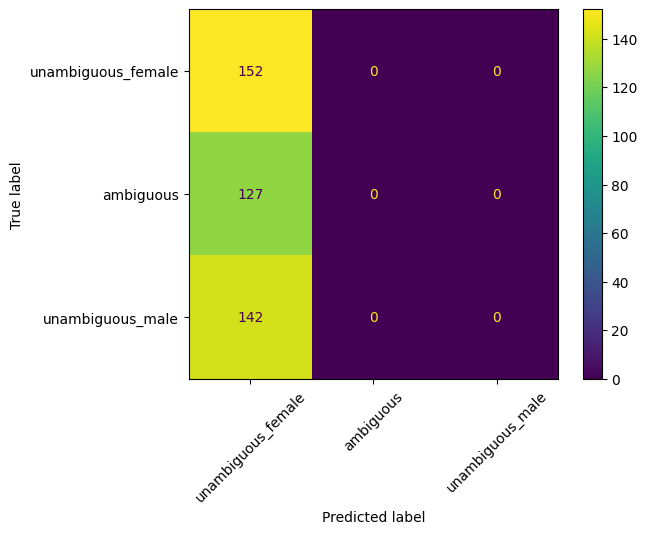

In [35]:
baseline_report(rule_results_path, 'lexical')

## Random Baseline

{'seed': 'attendant', 's1': '_', 's2': 'A flight attendant must handle demanding passengers while remaining professional.', 's3': '_', 'stereotype': 'female_stereotyped', 'dataset_type': 'fairtranslate', 'label': 'ambiguous', 'predicted': 'ambiguous'}
                    precision    recall  f1-score   support

         ambiguous      0.409     0.253     0.313       651
   unambiguous_all      0.022     0.281     0.041        32
unambiguous_female      0.274     0.237     0.254       464
  unambiguous_male      0.266     0.230     0.247       448

          accuracy                          0.243      1595
         macro avg      0.243     0.250     0.214      1595
      weighted avg      0.322     0.243     0.272      1595



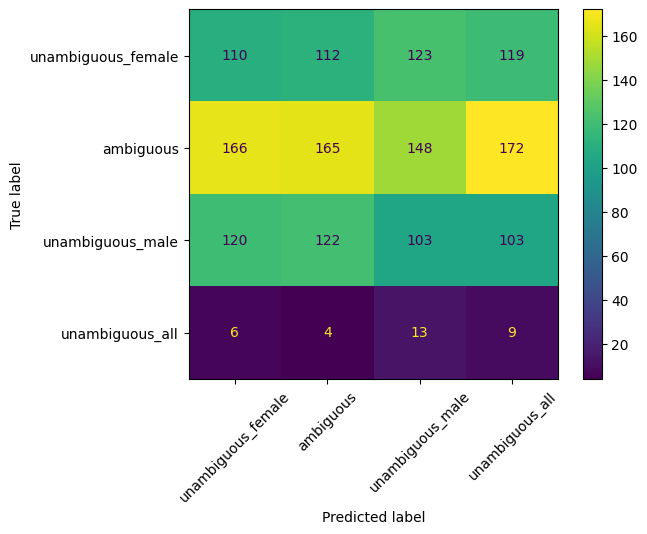

In [36]:
baseline_report(rule_results_path, 'all', baseline = 'random')

### FairTranslate

{'seed': 'attendant', 's1': '_', 's2': 'A flight attendant must handle demanding passengers while remaining professional.', 's3': '_', 'stereotype': 'female_stereotyped', 'dataset_type': 'fairtranslate', 'label': 'ambiguous', 'predicted': 'ambiguous'}
                    precision    recall  f1-score   support

         ambiguous      0.524     0.378     0.439       259
unambiguous_female      0.310     0.410     0.353       139
  unambiguous_male      0.302     0.359     0.328       142

          accuracy                          0.381       540
         macro avg      0.379     0.383     0.373       540
      weighted avg      0.410     0.381     0.388       540



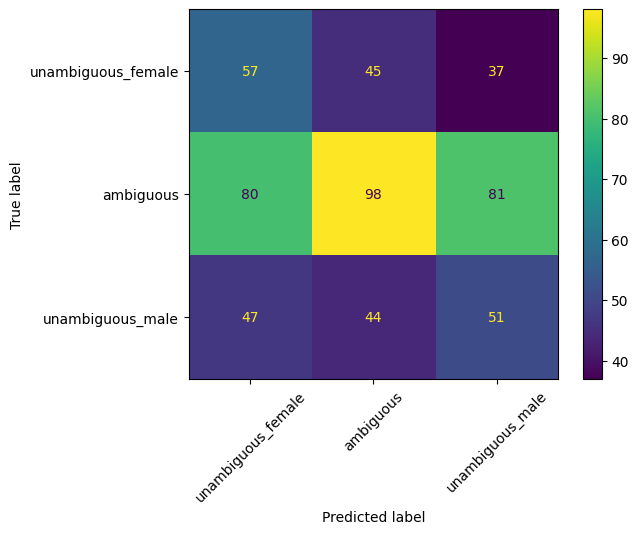

In [37]:
baseline_report(rule_results_path, 'fairtranslate', baseline = 'random')

### GeNTE

{'seed': 'attendant', 's1': '_', 's2': 'A flight attendant must handle demanding passengers while remaining professional.', 's3': '_', 'stereotype': 'female_stereotyped', 'dataset_type': 'fairtranslate', 'label': 'ambiguous', 'predicted': 'ambiguous'}
                    precision    recall  f1-score   support

         ambiguous      0.244     0.367     0.293        60
unambiguous_female      0.403     0.330     0.363        94
  unambiguous_male      0.360     0.307     0.331        88

          accuracy                          0.331       242
         macro avg      0.336     0.334     0.329       242
      weighted avg      0.348     0.331     0.334       242



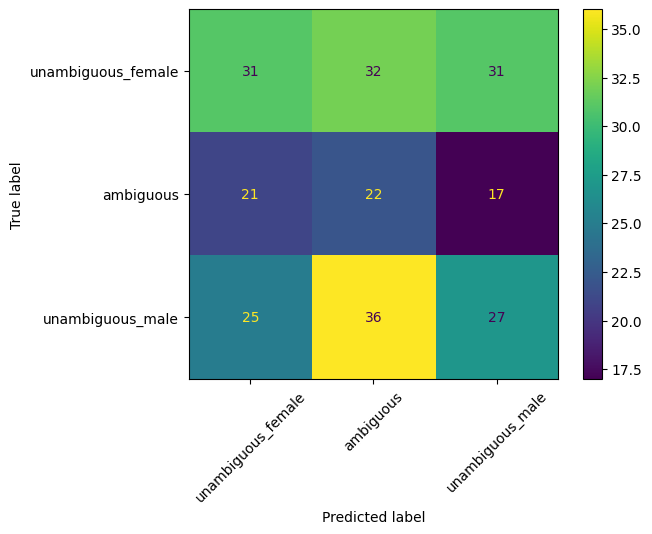

In [38]:
baseline_report(rule_results_path, 'gente', baseline = 'random')

### Glitter

{'seed': 'attendant', 's1': '_', 's2': 'A flight attendant must handle demanding passengers while remaining professional.', 's3': '_', 'stereotype': 'female_stereotyped', 'dataset_type': 'fairtranslate', 'label': 'ambiguous', 'predicted': 'ambiguous'}
                    precision    recall  f1-score   support

         ambiguous      0.552     0.259     0.352       205
   unambiguous_all      0.086     0.250     0.128        32
unambiguous_female      0.223     0.291     0.253        79
  unambiguous_male      0.200     0.263     0.227        76

          accuracy                          0.265       392
         macro avg      0.265     0.266     0.240       392
      weighted avg      0.380     0.265     0.290       392



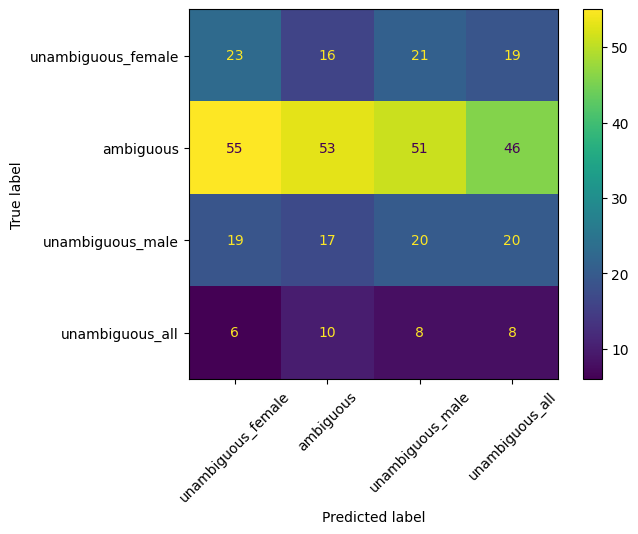

In [39]:
baseline_report(rule_results_path, 'glitter', baseline = 'random')

### Lexical Gender Extension

{'seed': 'attendant', 's1': '_', 's2': 'A flight attendant must handle demanding passengers while remaining professional.', 's3': '_', 'stereotype': 'female_stereotyped', 'dataset_type': 'fairtranslate', 'label': 'ambiguous', 'predicted': 'ambiguous'}
                    precision    recall  f1-score   support

         ambiguous      0.311     0.370     0.338       127
unambiguous_female      0.353     0.322     0.337       152
  unambiguous_male      0.321     0.296     0.308       142

          accuracy                          0.328       421
         macro avg      0.328     0.329     0.328       421
      weighted avg      0.329     0.328     0.327       421



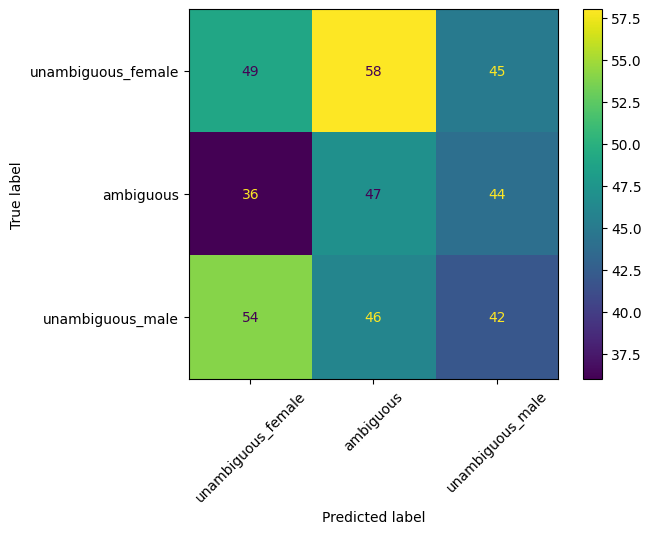

In [40]:
baseline_report(rule_results_path, 'lexical', baseline = 'random')

## Rule + LLM Second Run (seed 48)

### Overall

{'seed': 'attendant', 's1': '_', 's2': 'A flight attendant must handle demanding passengers while remaining professional.', 's3': '_', 'stereotype': 'female_stereotyped', 'dataset_type': 'fairtranslate', 'label': 'ambiguous', 'rule': 'ambiguous', 'predicted': 'ambiguous'}
                    precision    recall  f1-score   support

         ambiguous      0.758     0.945     0.841       651
   unambiguous_all      0.000     0.000     0.000        32
unambiguous_female      0.977     0.834     0.900       464
  unambiguous_male      0.929     0.792     0.855       448

          accuracy                          0.851      1595
         macro avg      0.666     0.643     0.649      1595
      weighted avg      0.855     0.851     0.845      1595



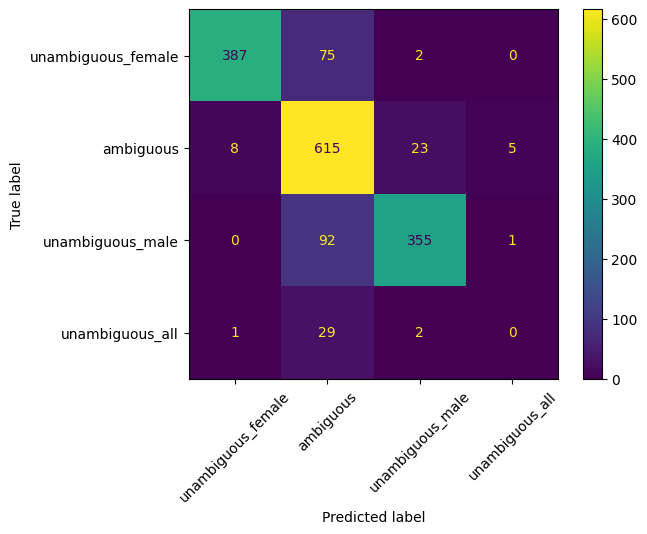

In [41]:
report_and_matrix(rule_llm_results_path48, 'all')

{'seed': 'attendant', 's1': '_', 's2': 'A flight attendant must handle demanding passengers while remaining professional.', 's3': '_', 'stereotype': 'female_stereotyped', 'dataset_type': 'fairtranslate', 'label': 'ambiguous', 'rule': 'ambiguous', 'predicted': 'ambiguous'}
                    precision    recall  f1-score   support

         ambiguous      0.944     0.985     0.964       259
unambiguous_female      0.992     0.935     0.963       139
  unambiguous_male      0.978     0.958     0.968       142

          accuracy                          0.965       540
         macro avg      0.972     0.959     0.965       540
      weighted avg      0.966     0.965     0.965       540



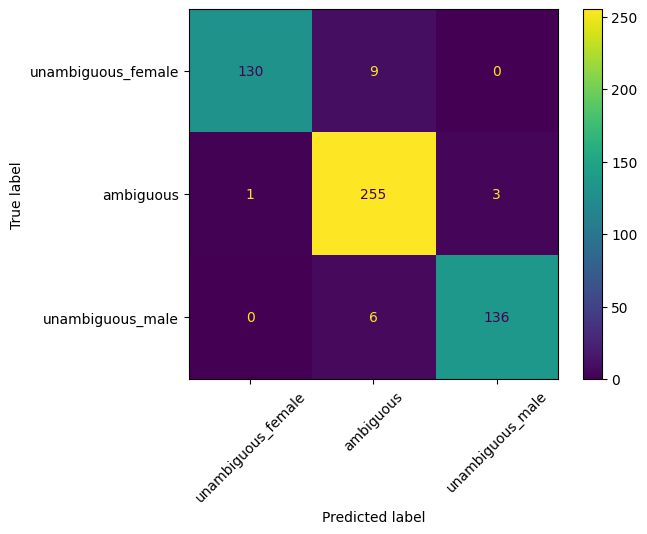

In [42]:
report_and_matrix(rule_llm_results_path48, 'fairtranslate')

{'seed': 'attendant', 's1': '_', 's2': 'A flight attendant must handle demanding passengers while remaining professional.', 's3': '_', 'stereotype': 'female_stereotyped', 'dataset_type': 'fairtranslate', 'label': 'ambiguous', 'rule': 'ambiguous', 'predicted': 'ambiguous'}
                    precision    recall  f1-score   support

         ambiguous      0.488     0.667     0.563        60
unambiguous_female      1.000     0.777     0.874        94
  unambiguous_male      0.770     0.761     0.766        88

          accuracy                          0.744       242
         macro avg      0.753     0.735     0.734       242
      weighted avg      0.789     0.744     0.758       242



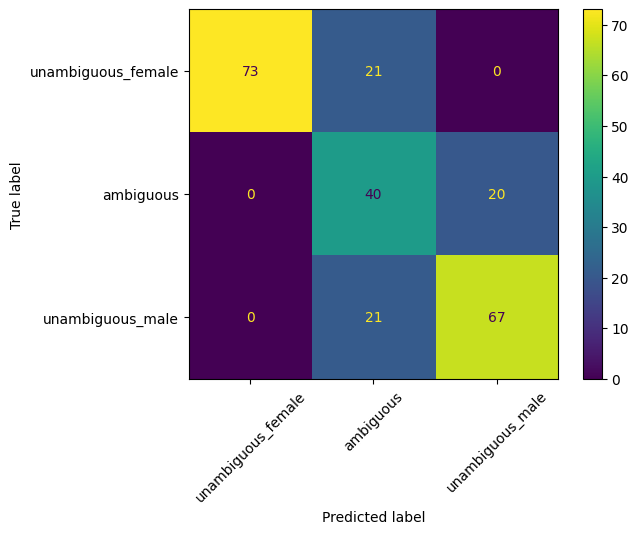

In [43]:
report_and_matrix(rule_llm_results_path48, 'gente')

{'seed': 'attendant', 's1': '_', 's2': 'A flight attendant must handle demanding passengers while remaining professional.', 's3': '_', 'stereotype': 'female_stereotyped', 'dataset_type': 'fairtranslate', 'label': 'ambiguous', 'rule': 'ambiguous', 'predicted': 'ambiguous'}
                    precision    recall  f1-score   support

         ambiguous      0.629     0.941     0.754       205
   unambiguous_all      0.000     0.000     0.000        32
unambiguous_female      0.818     0.456     0.585        79
  unambiguous_male      0.914     0.421     0.577        76

          accuracy                          0.666       392
         macro avg      0.590     0.455     0.479       392
      weighted avg      0.671     0.666     0.624       392



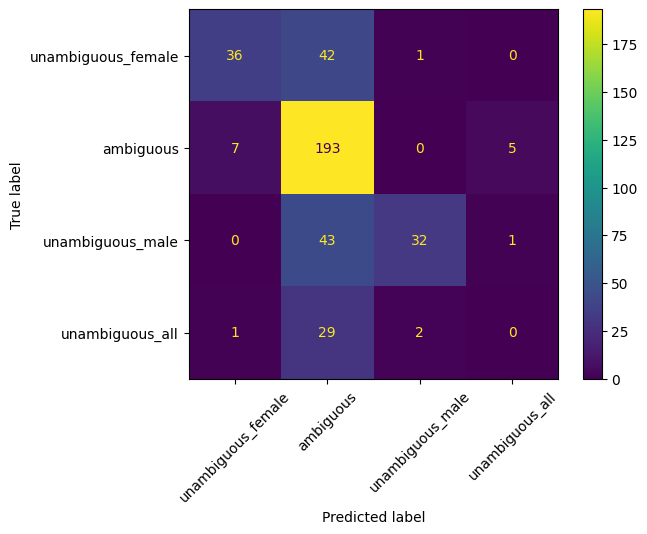

In [44]:
report_and_matrix(rule_llm_results_path48, 'glitter')

{'seed': 'attendant', 's1': '_', 's2': 'A flight attendant must handle demanding passengers while remaining professional.', 's3': '_', 'stereotype': 'female_stereotyped', 'dataset_type': 'fairtranslate', 'label': 'ambiguous', 'rule': 'ambiguous', 'predicted': 'ambiguous'}
                    precision    recall  f1-score   support

         ambiguous      0.836     1.000     0.910       127
unambiguous_female      1.000     0.974     0.987       152
  unambiguous_male      0.992     0.845     0.913       142

          accuracy                          0.938       421
         macro avg      0.942     0.940     0.937       421
      weighted avg      0.948     0.938     0.939       421



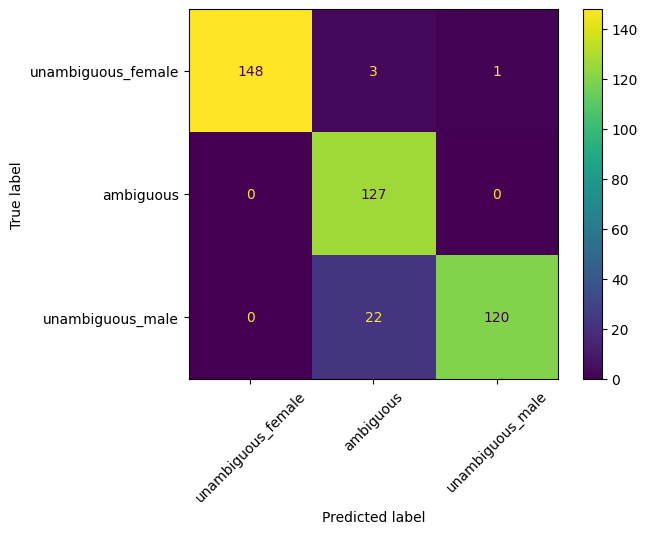

In [45]:
report_and_matrix(rule_llm_results_path48, 'lexical')

## Rule + LLM (seed 98)

{'seed': 'attendant', 's1': '_', 's2': 'A flight attendant must handle demanding passengers while remaining professional.', 's3': '_', 'stereotype': 'female_stereotyped', 'dataset_type': 'fairtranslate', 'label': 'ambiguous', 'rule': 'ambiguous', 'predicted': 'ambiguous'}
                    precision    recall  f1-score   support

         ambiguous      0.756     0.946     0.840       651
   unambiguous_all      0.000     0.000     0.000        32
unambiguous_female      0.980     0.834     0.901       464
  unambiguous_male      0.931     0.788     0.854       448

          accuracy                          0.850      1595
         macro avg      0.667     0.642     0.649      1595
      weighted avg      0.855     0.850     0.845      1595



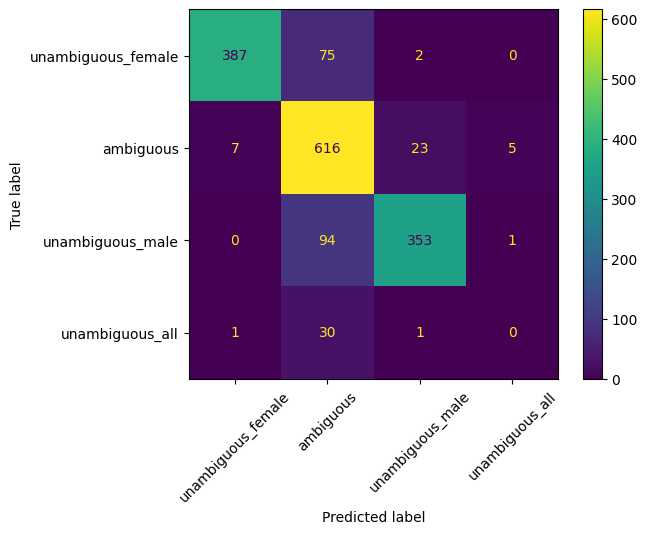

In [46]:
report_and_matrix(rule_llm_results_path98, 'all')

{'seed': 'attendant', 's1': '_', 's2': 'A flight attendant must handle demanding passengers while remaining professional.', 's3': '_', 'stereotype': 'female_stereotyped', 'dataset_type': 'fairtranslate', 'label': 'ambiguous', 'rule': 'ambiguous', 'predicted': 'ambiguous'}
                    precision    recall  f1-score   support

         ambiguous      0.944     0.985     0.964       259
unambiguous_female      0.992     0.935     0.963       139
  unambiguous_male      0.978     0.958     0.968       142

          accuracy                          0.965       540
         macro avg      0.972     0.959     0.965       540
      weighted avg      0.966     0.965     0.965       540



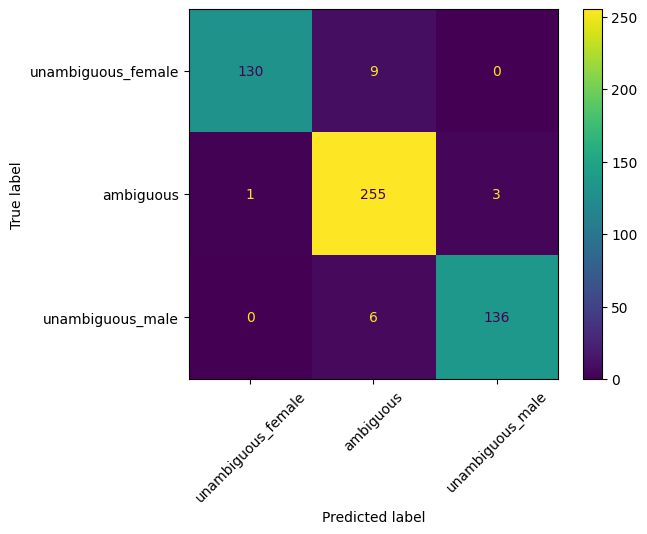

In [47]:
report_and_matrix(rule_llm_results_path98, 'fairtranslate')

{'seed': 'attendant', 's1': '_', 's2': 'A flight attendant must handle demanding passengers while remaining professional.', 's3': '_', 'stereotype': 'female_stereotyped', 'dataset_type': 'fairtranslate', 'label': 'ambiguous', 'rule': 'ambiguous', 'predicted': 'ambiguous'}
                    precision    recall  f1-score   support

         ambiguous      0.488     0.667     0.563        60
unambiguous_female      1.000     0.777     0.874        94
  unambiguous_male      0.770     0.761     0.766        88

          accuracy                          0.744       242
         macro avg      0.753     0.735     0.734       242
      weighted avg      0.789     0.744     0.758       242



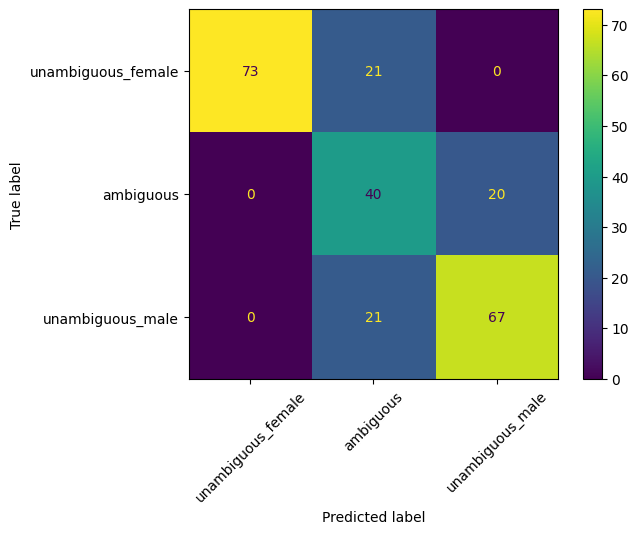

In [48]:
report_and_matrix(rule_llm_results_path98, 'gente')

{'seed': 'attendant', 's1': '_', 's2': 'A flight attendant must handle demanding passengers while remaining professional.', 's3': '_', 'stereotype': 'female_stereotyped', 'dataset_type': 'fairtranslate', 'label': 'ambiguous', 'rule': 'ambiguous', 'predicted': 'ambiguous'}
                    precision    recall  f1-score   support

         ambiguous      0.624     0.946     0.752       205
   unambiguous_all      0.000     0.000     0.000        32
unambiguous_female      0.837     0.456     0.590        79
  unambiguous_male      0.938     0.395     0.556        76

          accuracy                          0.663       392
         macro avg      0.600     0.449     0.474       392
      weighted avg      0.677     0.663     0.620       392



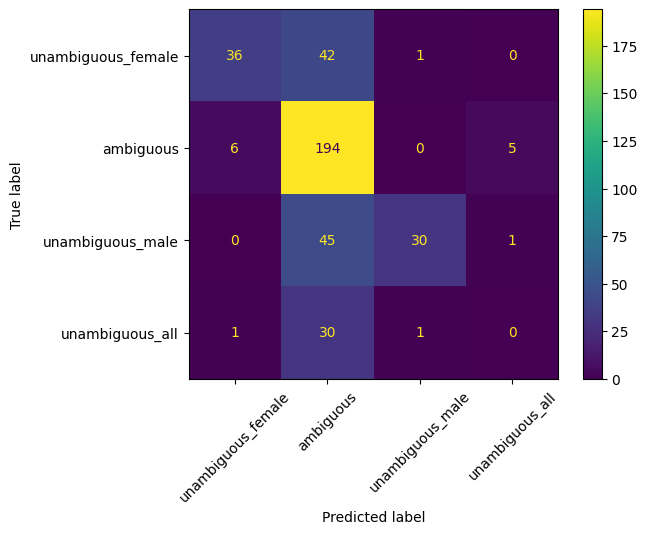

In [49]:
report_and_matrix(rule_llm_results_path98, 'glitter')

{'seed': 'attendant', 's1': '_', 's2': 'A flight attendant must handle demanding passengers while remaining professional.', 's3': '_', 'stereotype': 'female_stereotyped', 'dataset_type': 'fairtranslate', 'label': 'ambiguous', 'rule': 'ambiguous', 'predicted': 'ambiguous'}
                    precision    recall  f1-score   support

         ambiguous      0.836     1.000     0.910       127
unambiguous_female      1.000     0.974     0.987       152
  unambiguous_male      0.992     0.845     0.913       142

          accuracy                          0.938       421
         macro avg      0.942     0.940     0.937       421
      weighted avg      0.948     0.938     0.939       421



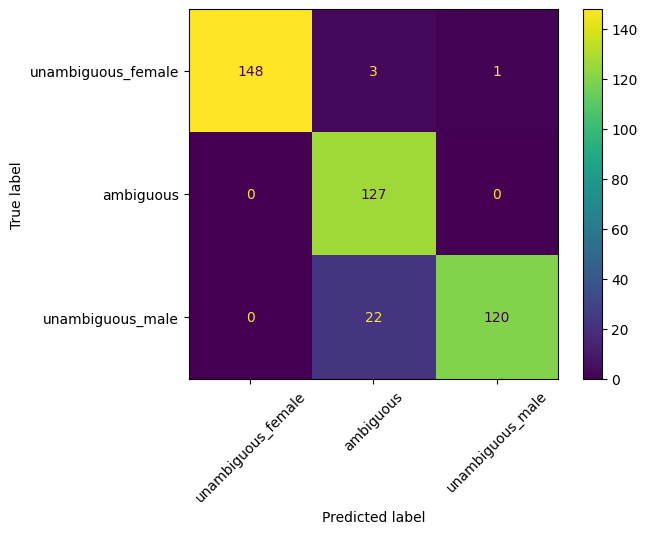

In [50]:
report_and_matrix(rule_llm_results_path98, 'lexical')

## Results per Cue Type

This section adds information on how linguistic gender was indicated in each passage (which type of cue was used)

In [51]:
rule_dict = file_to_dict(rule_results_path)

In [52]:
def add_cue_type(path, system='not llm', bert_help=None):
    if system == 'llm':
        with open(path) as infile:
            content = infile.read()
        lines = content.splitlines()
        headers = lines[0].split("\t")
        n_tabs = len(headers) - 1
        complete_lines = []
        current = ""
        for line in lines[1:]:
            current = current + "\n" + line if current else line
            if current.count("\t") == n_tabs:
                complete_lines.append(current)
                current = ""
        data_dct = []
        for line in complete_lines:
            values = line.split("\t")
            data_dct.append(dict(zip(headers, values)))
        label_map = {'AMBIGUOUS': 'ambiguous', 'UNAMBIGUOUS (FEMALE)': 'unambiguous_female',
                     'UNAMBIGUOUS (MALE)': 'unambiguous_male','UNAMBIGUOUS (BOTH)': 'unambiguous_all'}
        for dct in data_dct:
            dct['s1'] = dct.pop('preceding_context')
            dct['s2'] = dct.pop('matching_sentence')
            dct['s3'] = dct.pop('trailing_context')
            raw_prediction = dct.pop('llm_label')
            if raw_prediction in label_map:
                dct['predicted'] = label_map[raw_prediction]
            else:
                dct['predicted'] = raw_prediction
    elif system == 'bert':
        bert_dcts = file_to_dict(path)
        data_dct = file_to_dict(bert_help)
        bert_lookup = {}
        for bert in bert_dcts:
            bert_lookup[bert['sentence']] = bert['prediction']
        for rule in data_dct:
            if rule['s2'] in bert_lookup:
                rule['predicted'] = bert_lookup[rule['s2']]
    else:
        data_dct = file_to_dict(path)
    for dct in data_dct:
        if 'sentence' in dct:
            dct['s2'] = dct['sentence']
        if dct['dataset_type'] == 'fairtranslate' and dct['label'] != 'ambiguous':
            dct['cue_type'] = 'pronoun'
        elif dct['dataset_type'] == 'glitter':
            dct['cue_type'] = 'lexical_ref'
        elif dct['dataset_type'] == 'lexical' and dct['label'] != 'ambiguous':
            dct['cue_type'] = 'lexical'
        elif dct['dataset_type'] == 'gente' and dct['label'] != 'ambiguous':
            for word in dct['s2'].split(' '):
                if word.lower() in ['he', 'she', 'her', 'his', 'herself', 'himself', 'him']:
                    dct['cue_type'] = 'pronoun'
                    break
                elif word.lower().strip('.') in ['mr', 'ms', 'mrs', 'miss']:
                    dct['cue_type'] = 'title'
                    break
            if dct['seed'] in masc_set or dct['seed'] in fem_set:
                dct['cue_type'] = 'lexical'
            elif 'cue_type' not in dct:
                dct['cue_type'] = 'lexical_ref'
        else:
            dct['cue_type'] = 'no_cue'
    return data_dct

In [53]:
rule_cue = add_cue_type(rule_results_path)
logreg_cue = add_cue_type(logreg_results_path)
rule_llm_cue = add_cue_type(rule_llm_results_path)
qwen3b_cue = add_cue_type(qwen3b_results_path, 'llm')
qwen72b_cue = add_cue_type(qwen72b_results_path, 'llm')
bert_cue = add_cue_type(bert_results_path, system = 'bert', bert_help = rule_results_path)

In [54]:
print(rule_cue[5])
print()
print(logreg_cue[5])
print()
print(rule_llm_cue[5])
print()
print(qwen3b_cue[5])
print()
print(qwen72b_cue[5])

{'seed': 'spokesperson', 's1': '_', 's2': 'I should like to end by stressing that our distinguished spokesperson, Mr Rocard, took extensive account of the scientific observations and many of the suggestions in my opinion.', 's3': '_', 'stereotype': '_', 'dataset_type': 'gente', 'label': 'unambiguous_male', 'predicted': 'unambiguous_male', 'cue_type': 'title'}

{'seed': 'spokesperson', 'sentence': 'I should like to end by stressing that our distinguished spokesperson, Mr Rocard, took extensive account of the scientific observations and many of the suggestions in my opinion.', 'stereotype': '_', 'dataset_type': 'gente', 'label': 'unambiguous_male', 'predicted': 'unambiguous_male', 'lexical_gender': 'neutral', 'modifier_gender': 'none', 'plural_conj_cluster': 'sing_noplural_mn_neut', 'pronoun_gender': 'neutral', 'closest_masc_path': 'none', 'closest_fem_path': 'none', 's2': 'I should like to end by stressing that our distinguished spokesperson, Mr Rocard, took extensive account of the sci

In [55]:
cue = 'pronoun'

f1_pro_rule = f1(rule_cue, 'pronoun')

### Heatmap F1s per cue type

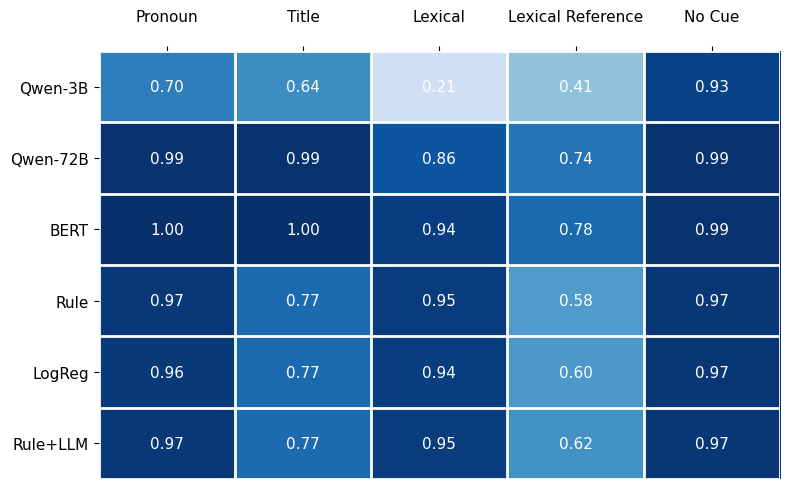

In [56]:
cues = ["pronoun", "title", "lexical", "lexical_ref", "no_cue"]
rows = ["Qwen-3B", "Qwen-72B", "BERT", "Rule", "LogReg", "Rule+LLM"]
cols = ["Pronoun\n", "Title\n", "Lexical\n", "Lexical Reference\n", "No Cue\n"]

data = np.array([[f1(qwen3b_cue, cue) for cue in cues],
    [f1(qwen72b_cue, cue) for cue in cues],
    [f1(bert_cue, cue) for cue in cues],  
    [f1(rule_cue, cue) for cue in cues],
    [f1(logreg_cue, cue) for cue in cues],
    [f1(rule_llm_cue, cue) for cue in cues]])

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(data, cmap="Blues", vmin=0.0, vmax=1.0, aspect="auto")

ax.set_xticks(np.arange(len(cols)))
ax.set_yticks(np.arange(len(rows)))
ax.set_xticklabels(cols, fontsize=11)
ax.set_yticklabels(rows, fontsize=11)
ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False)

for spine in ax.spines.values():
    spine.set_visible(False)

#white lines between the cells
ax.set_xticks(np.arange(-0.5, len(cols), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(rows), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=2)
ax.tick_params(which="minor", bottom=False, left=False)

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        val = data[i, j]
        if np.isnan(val):
            text = "---"
        else:
            text = f"{val:.2f}"
        ax.text(j, i, text, ha="center", va="center", color="white", fontsize=11)

plt.tight_layout()
# plt.savefig("../../confusion-matrices/heatmap.pdf", bbox_inches="tight")
plt.show()

### Pronouns

                    precision    recall  f1-score   support

         ambiguous      0.000     0.000     0.000         0
unambiguous_female      1.000     0.913     0.954       183
  unambiguous_male      1.000     0.957     0.978       186

          accuracy                          0.935       369
         macro avg      0.667     0.623     0.644       369
      weighted avg      1.000     0.935     0.966       369



/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

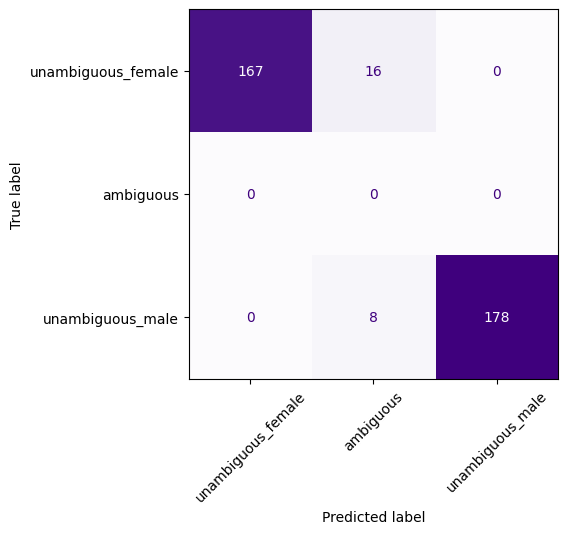

In [57]:
report_cue(rule_cue, 'pronoun')

                    precision    recall  f1-score   support

         ambiguous      0.000     0.000     0.000         0
unambiguous_female      1.000     0.907     0.951       183
  unambiguous_male      1.000     0.952     0.975       186

          accuracy                          0.930       369
         macro avg      0.667     0.620     0.642       369
      weighted avg      1.000     0.930     0.963       369



/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

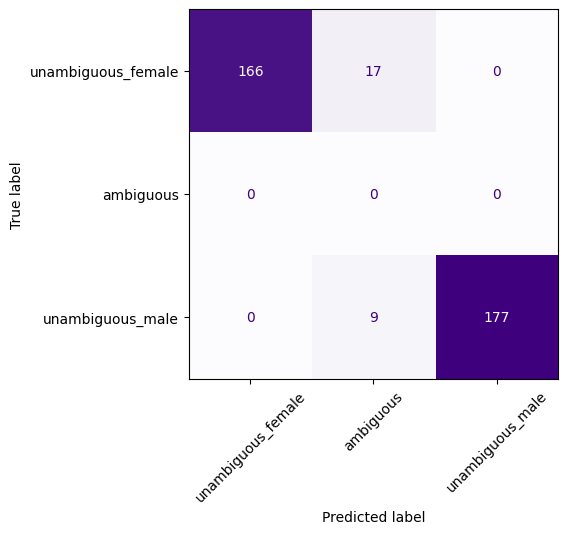

In [58]:
report_cue(logreg_cue, 'pronoun', system = 'logreg')

                    precision    recall  f1-score   support

unambiguous_female      1.000     1.000     1.000       183
  unambiguous_male      1.000     1.000     1.000       186

          accuracy                          1.000       369
         macro avg      1.000     1.000     1.000       369
      weighted avg      1.000     1.000     1.000       369



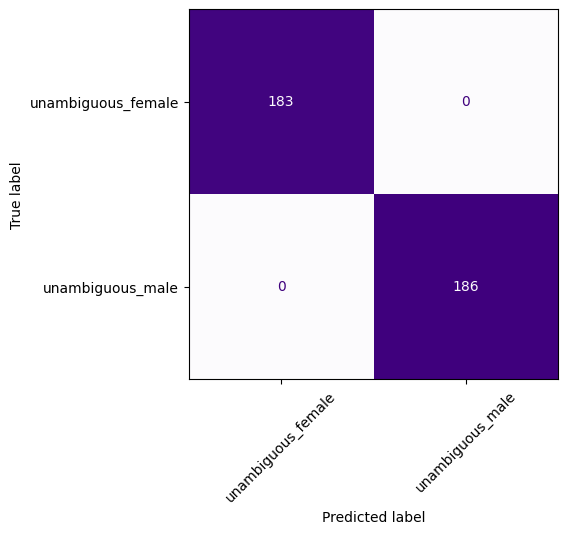

In [59]:
report_cue(bert_cue, 'pronoun', system = 'bert')

                    precision    recall  f1-score   support

         ambiguous      0.000     0.000     0.000         0
unambiguous_female      1.000     0.913     0.954       183
  unambiguous_male      1.000     0.957     0.978       186

          accuracy                          0.935       369
         macro avg      0.667     0.623     0.644       369
      weighted avg      1.000     0.935     0.966       369



/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

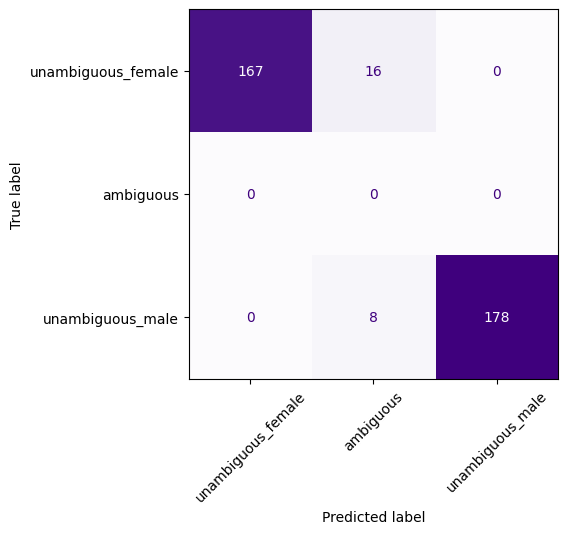

In [60]:
report_cue(rule_llm_cue, 'pronoun', system = 'rule_llm')

/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

                    precision    recall  f1-score   support

         ambiguous      0.000     0.000     0.000         0
unambiguous_female      0.991     0.579     0.731       183
  unambiguous_male      0.755     0.597     0.667       186

          accuracy                          0.588       369
         macro avg      0.582     0.392     0.466       369
      weighted avg      0.872     0.588     0.699       369



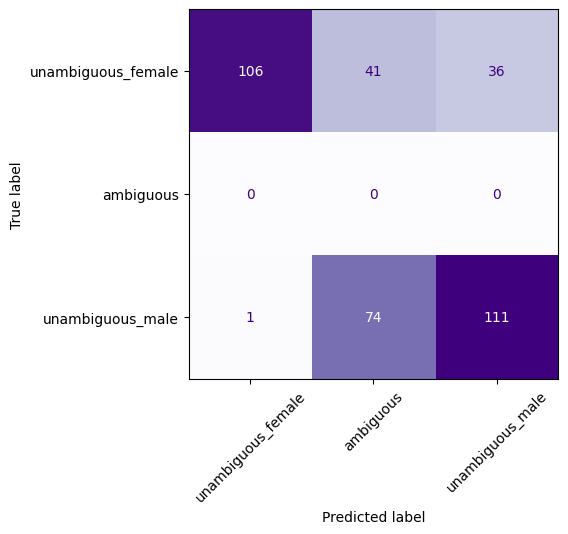

In [61]:
report_cue(qwen3b_cue, 'pronoun', system = 'qwen3b')

/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

                    precision    recall  f1-score   support

         ambiguous      0.000     0.000     0.000         0
unambiguous_female      1.000     0.995     0.997       183
  unambiguous_male      1.000     0.952     0.975       186

          accuracy                          0.973       369
         macro avg      0.667     0.649     0.657       369
      weighted avg      1.000     0.973     0.986       369



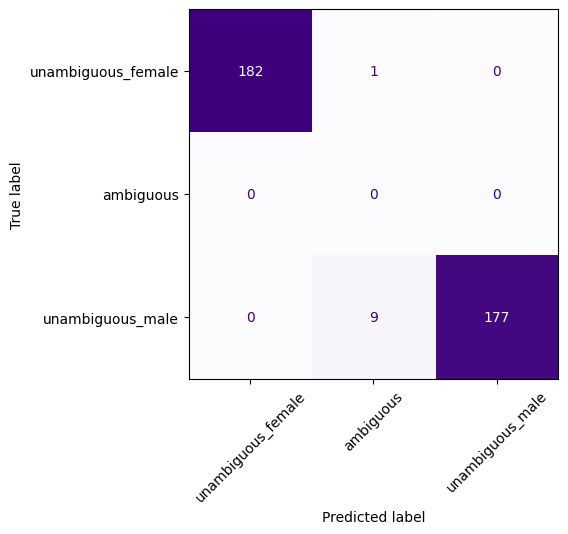

In [62]:
report_cue(qwen72b_cue, 'pronoun', system = 'qwen72b')

                    precision    recall  f1-score   support

         ambiguous      0.000     0.000     0.000         0
unambiguous_female      1.000     0.714     0.833        49
  unambiguous_male      1.000     0.537     0.698        41

          accuracy                          0.633        90
         macro avg      0.667     0.417     0.511        90
      weighted avg      1.000     0.633     0.772        90



/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

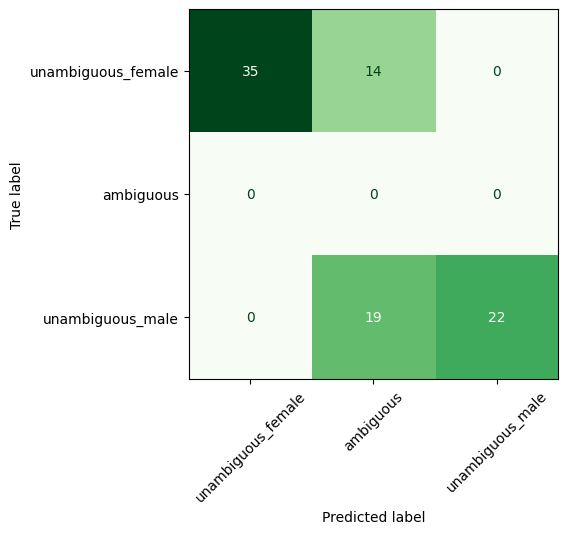

In [63]:
report_cue(rule_cue, 'title', system = 'rule', colour = 'Greens')

/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

                    precision    recall  f1-score   support

         ambiguous      0.000     0.000     0.000         0
unambiguous_female      1.000     0.714     0.833        49
  unambiguous_male      1.000     0.537     0.698        41

          accuracy                          0.633        90
         macro avg      0.667     0.417     0.511        90
      weighted avg      1.000     0.633     0.772        90



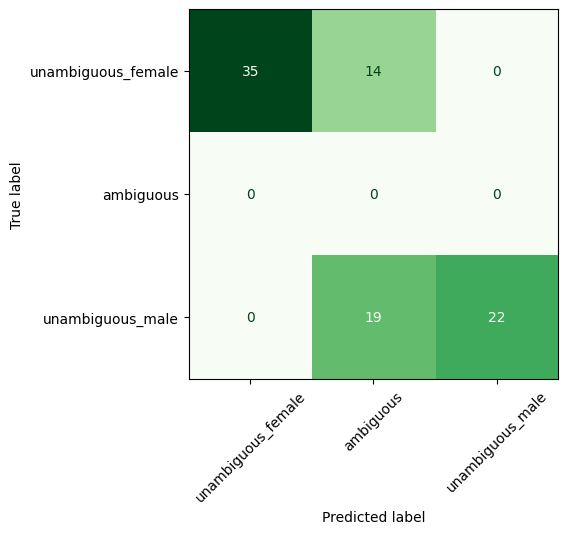

In [64]:
report_cue(rule_llm_cue, 'title', system = 'rule-llm', colour = 'Greens')

                    precision    recall  f1-score   support

unambiguous_female      1.000     1.000     1.000        49
  unambiguous_male      1.000     1.000     1.000        41

          accuracy                          1.000        90
         macro avg      1.000     1.000     1.000        90
      weighted avg      1.000     1.000     1.000        90



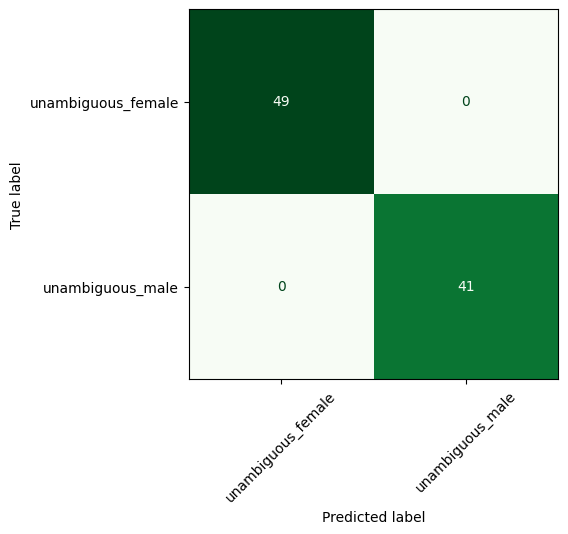

In [65]:
report_cue(bert_cue, 'title', system = 'bert', colour = 'Greens')

/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

                    precision    recall  f1-score   support

         ambiguous      0.000     0.000     0.000         0
unambiguous_female      1.000     0.694     0.819        49
  unambiguous_male      1.000     0.561     0.719        41

          accuracy                          0.633        90
         macro avg      0.667     0.418     0.513        90
      weighted avg      1.000     0.633     0.773        90



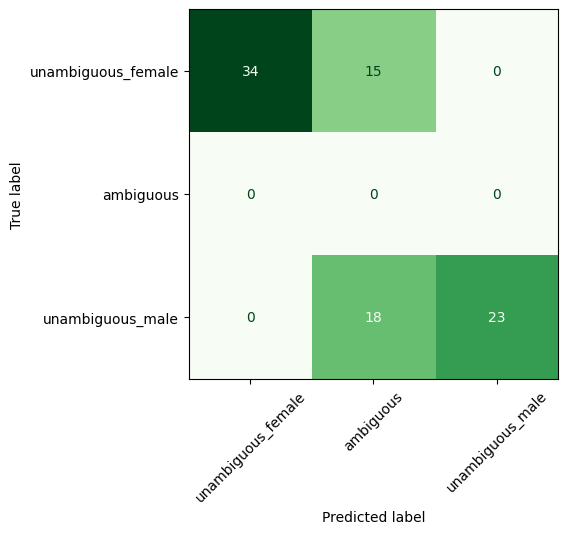

In [66]:
report_cue(logreg_cue, 'title', system = 'logreg', colour = 'Greens')

/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

                    precision    recall  f1-score   support

         ambiguous      0.000     0.000     0.000         0
   unambiguous_all      0.000     0.000     0.000         0
unambiguous_female      0.927     0.776     0.844        49
  unambiguous_male      0.632     0.293     0.400        41

          accuracy                          0.556        90
         macro avg      0.390     0.267     0.311        90
      weighted avg      0.792     0.556     0.642        90



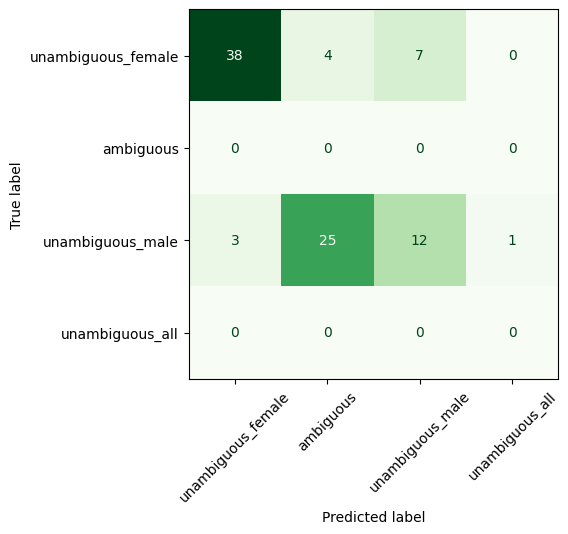

In [67]:
report_cue(qwen3b_cue, 'title', system = 'qwen3b', colour = 'Greens')

/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

                    precision    recall  f1-score   support

         ambiguous      0.000     0.000     0.000         0
unambiguous_female      1.000     0.980     0.990        49
  unambiguous_male      1.000     0.976     0.988        41

          accuracy                          0.978        90
         macro avg      0.667     0.652     0.659        90
      weighted avg      1.000     0.978     0.989        90



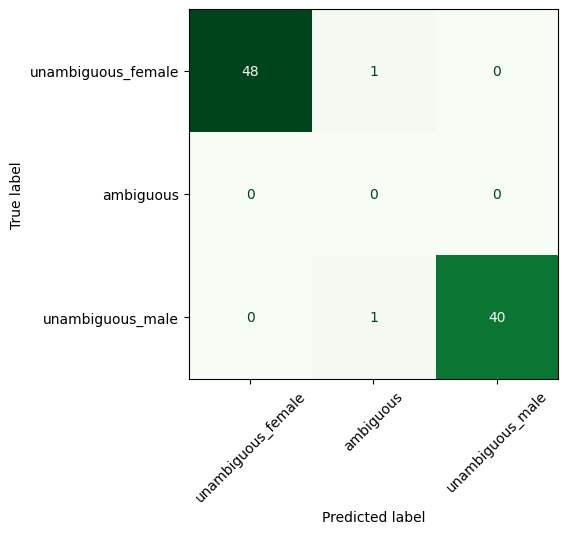

In [68]:
report_cue(qwen72b_cue, 'title', system = 'qwen72b', colour = 'Greens')

                    precision    recall  f1-score   support

         ambiguous      0.000     0.000     0.000         0
unambiguous_female      0.986     0.934     0.959       152
  unambiguous_male      0.970     0.889     0.928       144

          accuracy                          0.912       296
         macro avg      0.652     0.608     0.629       296
      weighted avg      0.978     0.912     0.944       296



/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

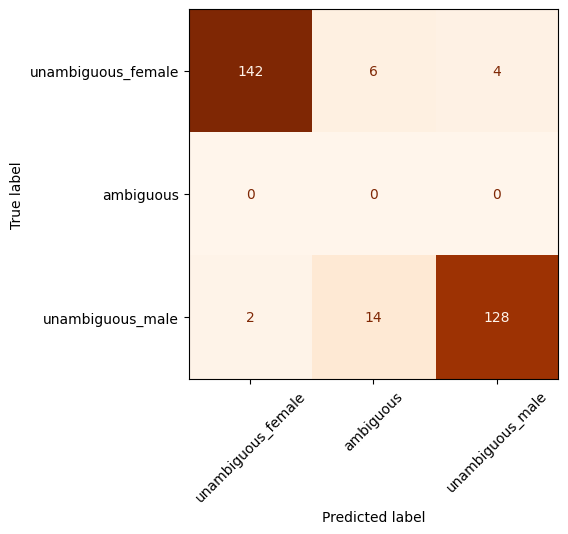

In [69]:
report_cue(bert_cue, 'lexical', system = 'bert', colour = 'Oranges')

/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

                    precision    recall  f1-score   support

         ambiguous      0.000     0.000     0.000         0
unambiguous_female      1.000     0.974     0.987       152
  unambiguous_male      0.992     0.847     0.914       144

          accuracy                          0.912       296
         macro avg      0.664     0.607     0.634       296
      weighted avg      0.996     0.912     0.951       296



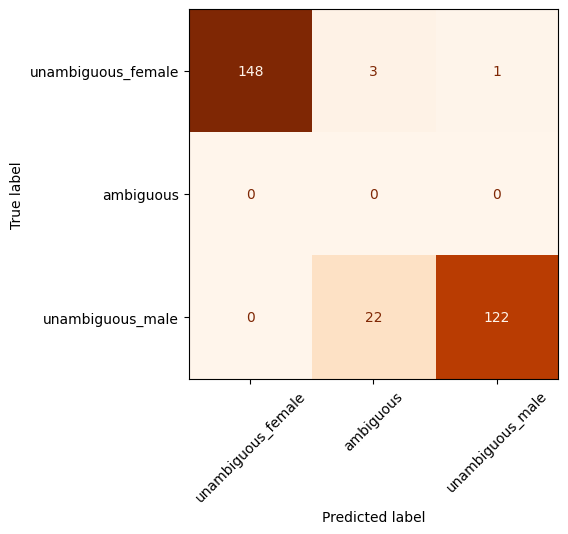

In [70]:
report_cue(rule_cue, 'lexical', system = 'rule', colour = 'Oranges')

/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

                    precision    recall  f1-score   support

         ambiguous      0.000     0.000     0.000         0
unambiguous_female      1.000     0.974     0.987       152
  unambiguous_male      0.992     0.847     0.914       144

          accuracy                          0.912       296
         macro avg      0.664     0.607     0.634       296
      weighted avg      0.996     0.912     0.951       296



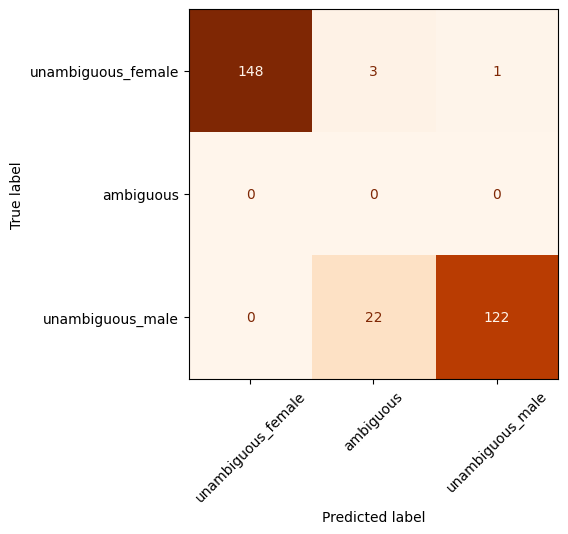

In [71]:
report_cue(rule_llm_cue, 'lexical', system = 'rule-llm', colour = 'Oranges')

/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

                    precision    recall  f1-score   support

         ambiguous      0.000     0.000     0.000         0
unambiguous_female      0.993     0.974     0.983       152
  unambiguous_male      0.992     0.819     0.897       144

          accuracy                          0.899       296
         macro avg      0.662     0.598     0.627       296
      weighted avg      0.992     0.899     0.942       296



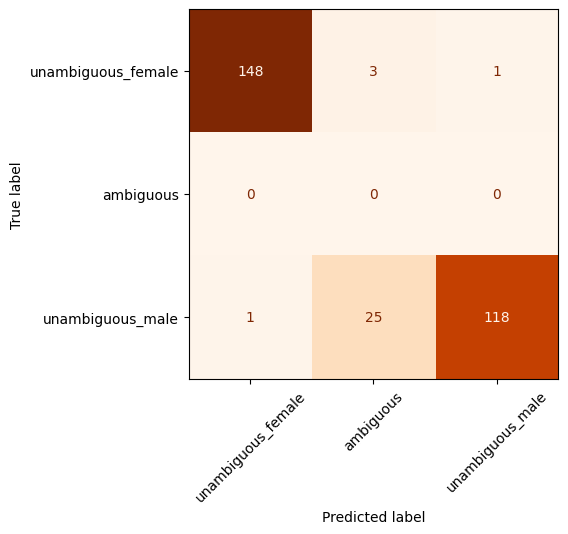

In [72]:
report_cue(logreg_cue, 'lexical', system = 'logreg', colour = 'Oranges')

/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

                    precision    recall  f1-score   support

         ambiguous      0.000     0.000     0.000         0
   unambiguous_all      0.000     0.000     0.000         0
unambiguous_female      0.449     0.145     0.219       152
  unambiguous_male      0.500     0.118     0.191       144

          accuracy                          0.132       296
         macro avg      0.237     0.066     0.102       296
      weighted avg      0.474     0.132     0.205       296



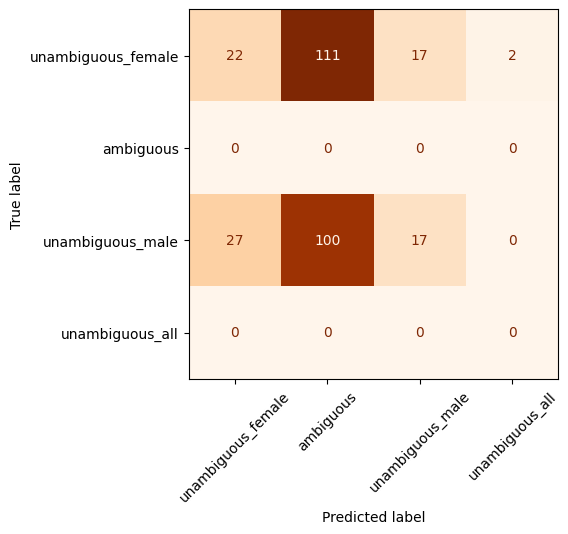

In [73]:
report_cue(qwen3b_cue, 'lexical', system = 'qwen3b', colour = 'Oranges')

/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

                    precision    recall  f1-score   support

         ambiguous      0.000     0.000     0.000         0
   unambiguous_all      0.000     0.000     0.000         0
unambiguous_female      1.000     0.836     0.910       152
  unambiguous_male      0.990     0.667     0.797       144

          accuracy                          0.753       296
         macro avg      0.497     0.376     0.427       296
      weighted avg      0.995     0.753     0.855       296



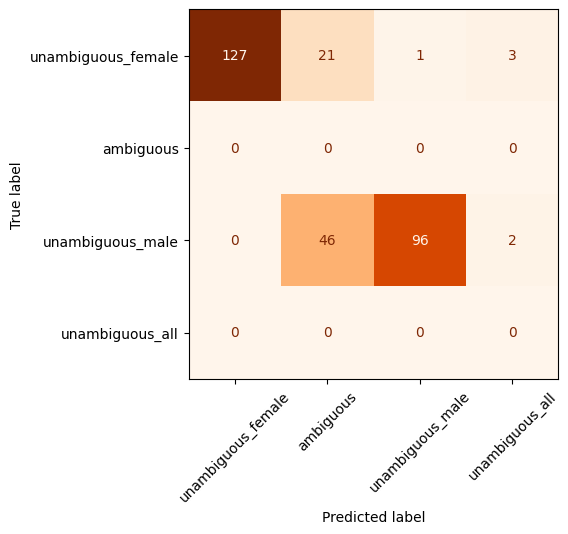

In [74]:
report_cue(qwen72b_cue, 'lexical', system = 'qwen72b', colour = 'Oranges')

                    precision    recall  f1-score   support

         ambiguous      0.719     0.873     0.789       205
   unambiguous_all      0.520     0.406     0.456        32
unambiguous_female      0.829     0.787     0.808        80
  unambiguous_male      0.909     0.519     0.661        77

          accuracy                          0.749       394
         macro avg      0.744     0.647     0.678       394
      weighted avg      0.762     0.749     0.741       394



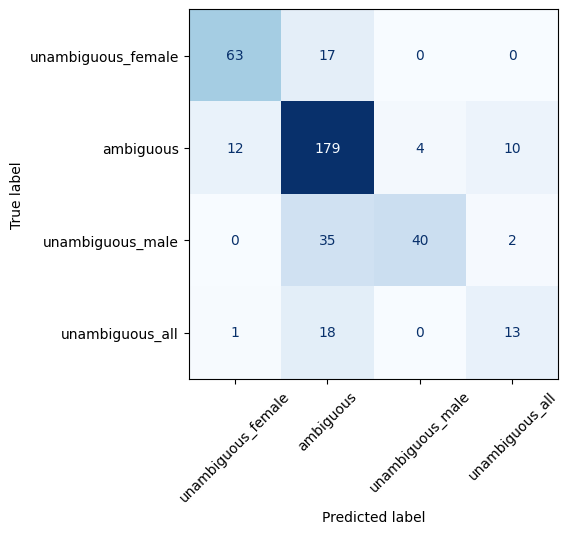

In [75]:
report_cue(qwen72b_cue, 'lexical_ref', system = 'qwen72b', colour = 'Blues')

                    precision    recall  f1-score   support

         ambiguous      0.524     0.912     0.665       205
   unambiguous_all      0.250     0.062     0.100        32
unambiguous_female      0.545     0.150     0.235        80
  unambiguous_male      0.143     0.013     0.024        77

          accuracy                          0.513       394
         macro avg      0.366     0.284     0.256       394
      weighted avg      0.432     0.513     0.407       394



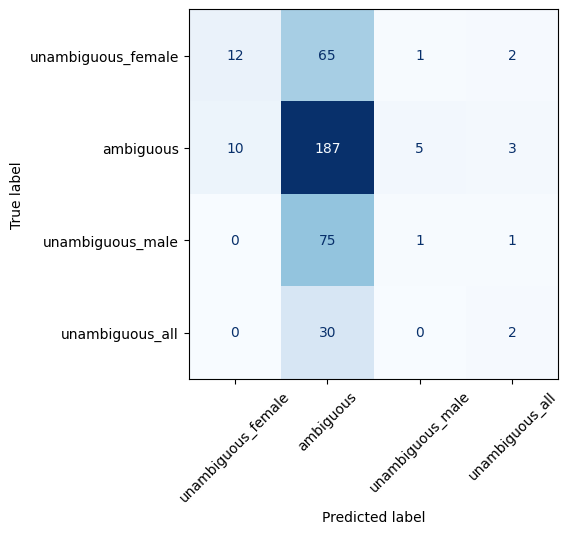

In [76]:
report_cue(qwen3b_cue, 'lexical_ref', system = 'qwen3b', colour = 'Blues')

                    precision    recall  f1-score   support

         ambiguous      0.597     0.946     0.732       205
   unambiguous_all      0.000     0.000     0.000        32
unambiguous_female      0.821     0.400     0.538        80
  unambiguous_male      0.920     0.299     0.451        77

          accuracy                          0.632       394
         macro avg      0.584     0.411     0.430       394
      weighted avg      0.657     0.632     0.578       394



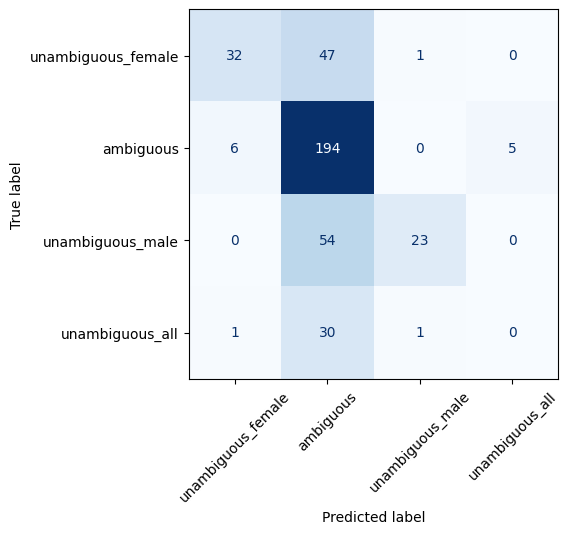

In [77]:
report_cue(rule_cue, 'lexical_ref', system = 'rule', colour = 'Blues')

                    precision    recall  f1-score   support

         ambiguous      0.625     0.941     0.751       205
   unambiguous_all      0.000     0.000     0.000        32
unambiguous_female      0.818     0.450     0.581        80
  unambiguous_male      0.943     0.429     0.589        77

          accuracy                          0.665       394
         macro avg      0.596     0.455     0.480       394
      weighted avg      0.675     0.665     0.624       394



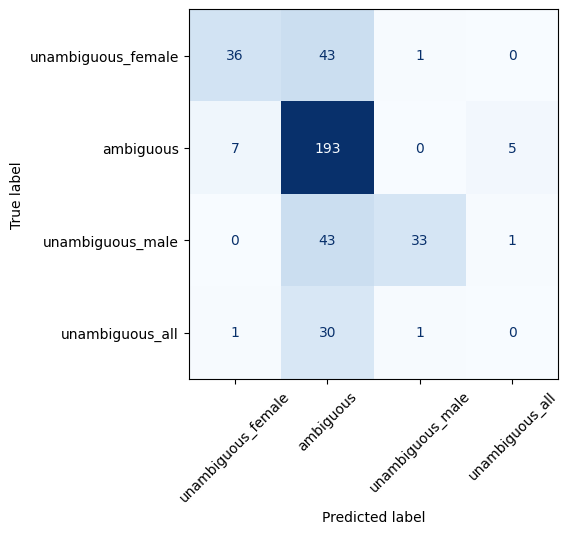

In [78]:
report_cue(rule_llm_cue, 'lexical_ref', system = 'rule-llm', colour = 'Blues')

                    precision    recall  f1-score   support

         ambiguous      0.626     0.922     0.746       205
   unambiguous_all      0.000     0.000     0.000        32
unambiguous_female      0.825     0.412     0.550        80
  unambiguous_male      0.615     0.416     0.496        77

          accuracy                          0.645       394
         macro avg      0.517     0.438     0.448       394
      weighted avg      0.613     0.645     0.597       394



/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

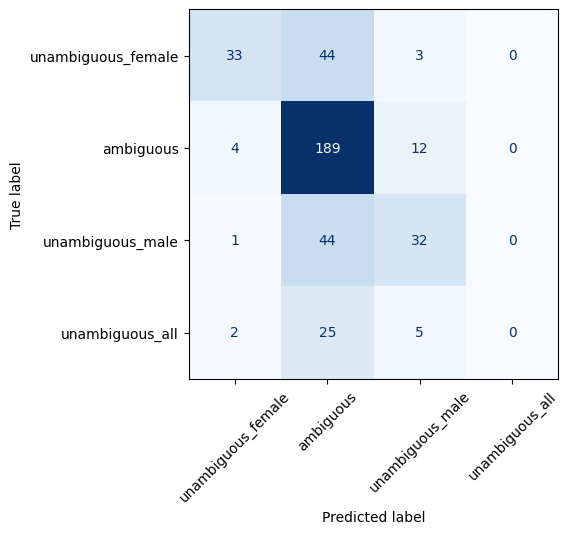

In [79]:
report_cue(logreg_cue, 'lexical_ref', system = 'logreg', colour = 'Blues')

                    precision    recall  f1-score   support

         ambiguous      0.805     0.844     0.824       205
   unambiguous_all      0.737     0.438     0.549        32
unambiguous_female      0.744     0.800     0.771        80
  unambiguous_male      0.770     0.740     0.755        77

          accuracy                          0.782       394
         macro avg      0.764     0.705     0.725       394
      weighted avg      0.780     0.782     0.777       394



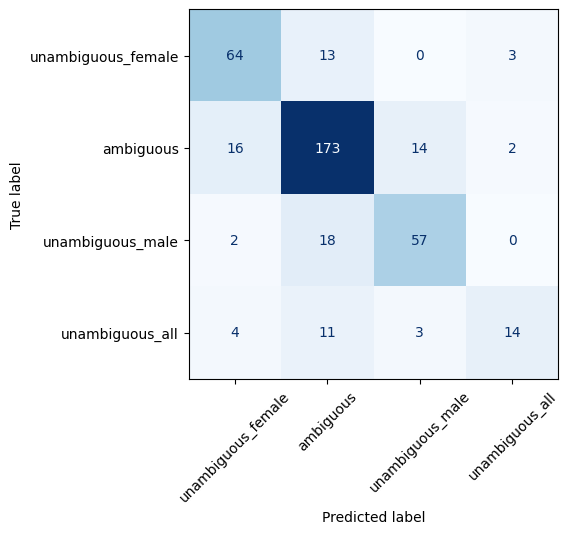

In [80]:
report_cue(bert_cue, 'lexical_ref', system = 'bert', colour = 'Blues')

                    precision    recall  f1-score   support

         ambiguous      1.000     0.978     0.989       446
unambiguous_female      0.000     0.000     0.000         0
  unambiguous_male      0.000     0.000     0.000         0

          accuracy                          0.978       446
         macro avg      0.333     0.326     0.330       446
      weighted avg      1.000     0.978     0.989       446



/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

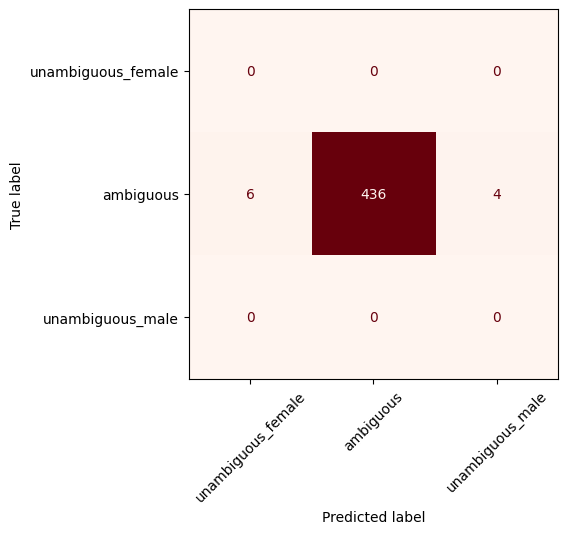

In [81]:
report_cue(bert_cue, 'no_cue', system = 'bert', colour = 'Reds')

                    precision    recall  f1-score   support

         ambiguous      1.000     0.980     0.990       446
unambiguous_female      0.000     0.000     0.000         0
  unambiguous_male      0.000     0.000     0.000         0

          accuracy                          0.980       446
         macro avg      0.333     0.327     0.330       446
      weighted avg      1.000     0.980     0.990       446



/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

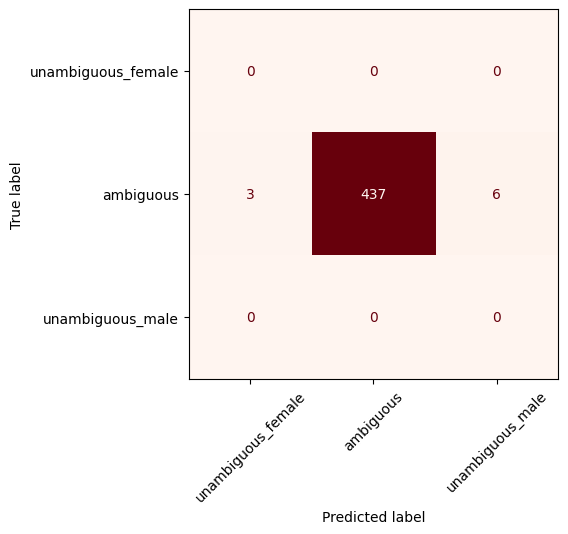

In [82]:
report_cue(qwen72b_cue, 'no_cue', system = 'qwen72b', colour = 'Reds')

/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

                    precision    recall  f1-score   support

         ambiguous      1.000     0.874     0.933       446
   unambiguous_all      0.000     0.000     0.000         0
unambiguous_female      0.000     0.000     0.000         0
  unambiguous_male      0.000     0.000     0.000         0

          accuracy                          0.874       446
         macro avg      0.250     0.219     0.233       446
      weighted avg      1.000     0.874     0.933       446



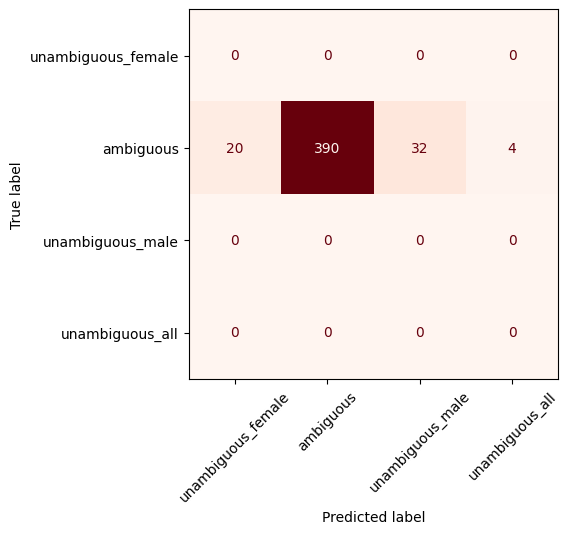

In [83]:
report_cue(qwen3b_cue, 'no_cue', system = 'qwen3b', colour = 'Reds')

                    precision    recall  f1-score   support

         ambiguous      1.000     0.948     0.974       446
unambiguous_female      0.000     0.000     0.000         0
  unambiguous_male      0.000     0.000     0.000         0

          accuracy                          0.948       446
         macro avg      0.333     0.316     0.325       446
      weighted avg      1.000     0.948     0.974       446



/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

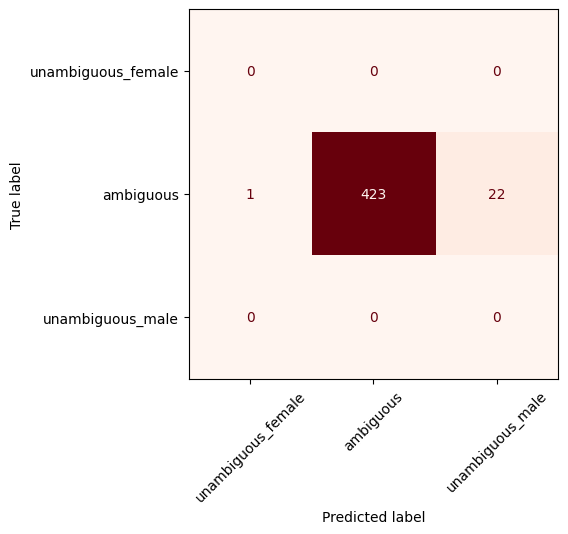

In [84]:
report_cue(logreg_cue, 'no_cue', system = 'logreg', colour = 'Reds')

/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

                    precision    recall  f1-score   support

         ambiguous      1.000     0.946     0.972       446
unambiguous_female      0.000     0.000     0.000         0
  unambiguous_male      0.000     0.000     0.000         0

          accuracy                          0.946       446
         macro avg      0.333     0.315     0.324       446
      weighted avg      1.000     0.946     0.972       446



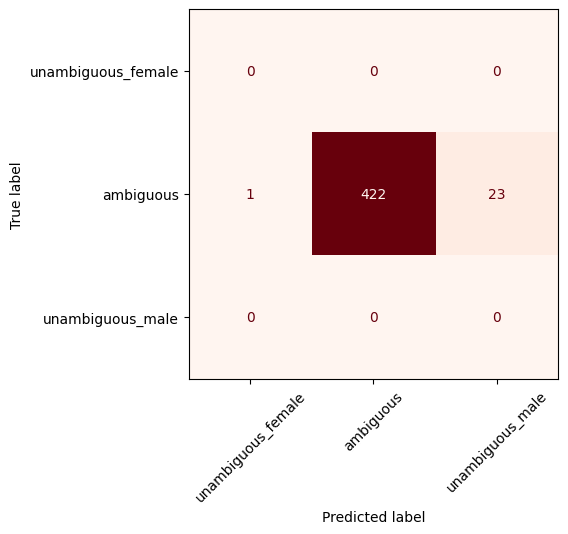

In [85]:
report_cue(rule_cue, 'no_cue', system = 'rule', colour = 'Reds')

/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

                    precision    recall  f1-score   support

         ambiguous      1.000     0.946     0.972       446
unambiguous_female      0.000     0.000     0.000         0
  unambiguous_male      0.000     0.000     0.000         0

          accuracy                          0.946       446
         macro avg      0.333     0.315     0.324       446
      weighted avg      1.000     0.946     0.972       446



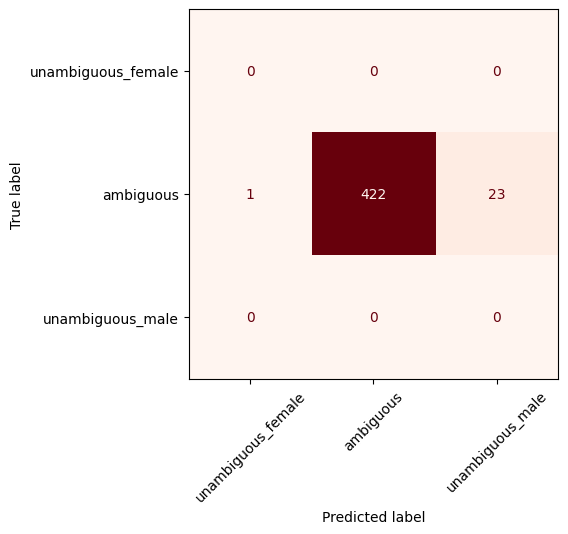

In [86]:
report_cue(rule_llm_cue, 'no_cue', system = 'rule-llm', colour = 'Reds')

## Qualitative Analysis

In [87]:
seeds = []
for dct in qwen3b_cue:
    if dct['label'] == 'ambiguous' and dct['predicted'] == 'unambiguous_all' and dct['cue_type'] == 'lexical_ref':
        #print(dct['seed'], dct['s2'], dct['stereotype'], dct['label'])
        #print()

        seeds.append(dct['seed'])

In [88]:
seeds = []
for dct in rule_llm_cue:
    if dct['label'] == 'ambiguous' and dct['predicted'] == 'unambiguous_all' and dct['cue_type'] == 'lexical_ref':
        #print(dct['seed'], dct['s2'], dct['stereotype'], dct['label'])
        #print()

        seeds.append(dct['seed'])

In [89]:
seeds = []
for dct in qwen72b_cue:
    if dct['label'] == 'ambiguous' and dct['predicted'] == 'unambiguous_all' and dct['cue_type'] == 'lexical_ref':
        print(dct['seed'], dct['s2'], dct['stereotype'], dct['label'])
        print()

        seeds.append(dct['seed'])

settlers Among the hardy settlers was a group led by Abigail and her brothers, pioneers in establishing new roots on the open plains. _ ambiguous

colleagues Colleagues, such as John and Emily, supported each other's professional development and goals. _ ambiguous

sailors The sailors, including many women, exhibited skill and resilience during challenging expeditions. _ ambiguous

tutors "Other ""tutors"" included Benny Hill, Harry Secombe, Dick Emery, Bernard Bresslaw, Hattie Jacques, and Bruce Forsyth – together with a young Julie Andrews as Archie's girlfriend." _ ambiguous

engineers The engineers working there, some of whom are women, have already made significant strides in developing new materials for construction industry applications. _ ambiguous

mechanics "The word ""colored"" was added to the previous name apparently by the public media of the time, thus labeling it the ""Colored National Labor Union."" The ""Colored"" National Labor Union was a post-civil war organization

In [90]:
seeds = []
for dct in bert_cue:
    if dct['label'] == 'ambiguous' and dct['predicted'] == 'unambiguous_all' and dct['cue_type'] == 'lexical_ref':
        #print(dct['seed'], dct['s2'], dct['stereotype'], dct['label'])
        #print()

        seeds.append(dct['seed'])

In [91]:
seeds = []
for dct in rule_cue:
    if dct['label'] == 'ambiguous' and dct['predicted'] == 'unambiguous_all' and dct['cue_type'] == 'lexical_ref':
        #print(dct['seed'], dct['s2'], dct['stereotype'], dct['label'])
        #print()

        seeds.append(dct['seed'])

In [92]:
#for noun, count in Counter(seeds).most_common():
#    print(noun, count)

In [93]:
features = file_to_dict(logreg_results_path)

print(features[0])

{'seed': 'attendant', 'sentence': 'A flight attendant must handle demanding passengers while remaining professional.', 'stereotype': 'female_stereotyped', 'dataset_type': 'fairtranslate', 'label': 'ambiguous', 'predicted': 'ambiguous', 'lexical_gender': 'neutral', 'modifier_gender': 'none', 'plural_conj_cluster': 'sing_noplural_n_neut', 'pronoun_gender': 'neutral', 'closest_masc_path': 'none', 'closest_fem_path': 'none'}


In [94]:
feature_lookup = {}
for feature in features:
    key = (feature['seed'], feature['sentence'])
    feature_lookup[key] = feature

false_negatives = []
unmatched = 0

for cue in rule_cue:
    if cue['label'] == 'unambiguous_female' and cue['predicted'] == 'ambiguous' and cue['dataset_type'] == 'glitter':
        key = (cue['seed'], cue['s2'])
        if key not in feature_lookup:
            unmatched += 1
            continue
        feature = feature_lookup[key]
        false_negatives.append(feature['closest_fem_path'])

print('false negatives:', len(false_negatives))
print('unmatched:', unmatched)


#print(false_negatives[:100])

false negatives: 47
unmatched: 0


In [95]:
false_negatives = []

for feature, cue in zip(features, rule_cue):
    if cue['label'] == 'unambiguous_female' and cue['predicted'] == 'ambiguous' and cue['dataset_type'] == 'glitter':
        false_negatives.append(feature)

In [96]:
true_positives = []
unmatched = 0
multiple_matches = 0

for cue in rule_cue:
    if cue['label'] == 'unambiguous_female' and cue['predicted'] == 'unambiguous_female' and cue['dataset_type'] == 'glitter':
        matches = []
        for feature in features:
            if cue['s2'] in feature['sentence'] and cue['seed'] == feature['seed']:
                matches.append(feature)

        if len(matches) == 0:
            unmatched += 1
            continue
        if len(matches) > 1:
            multiple_matches += 1

        feature = matches[0]
        true_positives.append(feature)

print('true positives:', len(true_positives))
print('unmatched:', unmatched)
print('with multiple matches:', multiple_matches)

true positives: 31
unmatched: 0
with multiple matches: 0


In [97]:
true_negatives = []

for feature, cue in zip(features, rule_cue):
    if cue['label'] == 'ambiguous' and cue['predicted'] == 'ambiguous' and cue['dataset_type'] == 'glitter':
        true_negatives.append(feature['closest_fem_path'])



In [98]:
relevant_modifier = {'unambiguous_female': 'fem', 'unambiguous_male': 'masc', 'unambiguous_all': 'both'}

def cue_stats(matched, label, title=''):
    total = len(matched)
    print(title)
    if total == 0:
        print('  no examples')
        print()
        return

    no_cue = 0
    modifier_count = 0

    for f in matched:
        if f['closest_fem_path'] == 'none' and f['closest_masc_path'] == 'none':
            no_cue += 1

        if label in relevant_modifier:
            if f['modifier_gender'] == relevant_modifier[label]:
                modifier_count += 1

    print('  total:', total)
    print('  no gender cue in sentence:', no_cue, '(' + str(round(no_cue / total * 100, 1)) + '%)')

    if label in relevant_modifier:
        print('  gender via modifier (' + relevant_modifier[label] + '):',
              modifier_count, '(' + str(round(modifier_count / total * 100, 1)) + '%)')
    print()

In [99]:
def match_and_plot(rule_cue, features, label, predicted, cue_type, title='', top_n=15):
    matched = []
    unmatched = 0
    multiple_matches = 0
    for cue in rule_cue:
        if cue['cue_type'] != cue_type:
            continue
        if predicted.startswith('not_'):
            if cue['predicted'] == predicted[len('not_'):]:
                continue
        else:
            if cue['predicted'] != predicted:
                continue
        if label.startswith('not_'):
            if cue['label'] == label[len('not_'):]:
                continue
        else:
            if cue['label'] != label:
                continue
        matches = []
        for feature in features:
            if cue['s2'] in feature['sentence'] and cue['seed'] == feature['seed']:
                matches.append(feature)
        if len(matches) == 0:
            unmatched += 1
            continue
        if len(matches) > 1:
            multiple_matches += 1
        feature = matches[0]
        matched.append(feature)
    #print(title)
    #print('matched:', len(matched))
    #print('unmatched:', unmatched)
    #print('with multiple matches:', multiple_matches)
    #if len(matched) == 0:
    #    print('nothing to plot')
    #    print()
        return matched
    #feature_keys = ['lexical_gender',
    #     'modifier_gender',
    #     'plural_conj_cluster',
    #     'pronoun_gender',
    #     'closest_masc_path',
#         'closest_fem_path']
     #counts = Counter()
    # for feature_dict in matched:
    #     for feature_name in feature_keys:
    #         value = feature_dict[feature_name]
    #         pair = feature_name + '=' + str(value)
    #         counts[pair] += 1
    # total = len(matched)
    # top_pairs = counts.most_common(top_n)
    # labels = []
    # values = []
    # for pair, count in top_pairs:
    #     labels.append(pair)
    #     values.append(count)
    # percentages = []
    # for count in values:
    #     percentages.append(count / total * 100)
    # fig, ax = plt.subplots(figsize=(10, 5))
    # bars = ax.bar(labels, percentages)
    # for bar in bars:
    #     ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
    #             f'{bar.get_height():.1f}%', ha='center')
    # ax.set_ylabel('Percentage of examples')
    # ax.set_xlabel('feature=value')
    # ax.set_title(title)
    # plt.xticks(rotation=45, ha='right')
    # plt.tight_layout()
    # plt.show()
    return matched

In [100]:
all_labels = ['unambiguous_female', 'unambiguous_male', 'unambiguous_all', 'ambiguous']

systems = {'rule': rule_cue,
    'logreg': logreg_cue,
    'rule_llm': rule_llm_cue,
    'qwen3b': qwen3b_cue,
    'qwen72b': qwen72b_cue,
    'bert': bert_cue}

results = {}

for system_name, system_list in systems.items():
    results[system_name] = {}
    for lab in all_labels:
        tp = match_and_plot(system_list, features, lab, lab, 'lexical_ref',
                            title=system_name + ' TP ' + lab)
        fp = match_and_plot(system_list, features, 'not_' + lab, lab, 'lexical_ref',
                            title=system_name + ' FP ' + lab)
        fn = match_and_plot(system_list, features, lab, 'not_' + lab, 'lexical_ref',
                            title=system_name + ' FN ' + lab)
        results[system_name][lab] = {'tp': tp, 'fp': fp, 'fn': fn}

for lab in all_labels:
    subset = []
    for f in features:
        if f['label'] == lab:
            subset.append(f)
    #cue_stats(subset, lab, title='OVERALL ' + lab)

In [101]:
#for system_name in results:
#    for lab in all_labels:
#        cue_stats(results[system_name][lab]['tp'], lab, title=system_name + ' TP ' + lab)
#        cue_stats(results[system_name][lab]['fp'], lab, title=system_name + ' FP ' + lab)
#        cue_stats(results[system_name][lab]['fn'], lab, title=system_name + ' FN ' + lab)

In [102]:
def lexical_cue_type(positions, cue_values, mod_values, color_mod, color_rest, label_prefix):
    rest_values = []
    for i in range(len(cue_values)):
        rest_values.append(cue_values[i] - mod_values[i])

    bars_mod = ax.bar(positions, mod_values, width,
                      color=color_mod, label=label_prefix + ' through modifier')
    bars_rest = ax.bar(positions, rest_values, width, bottom=mod_values,
                       color=color_rest, label=label_prefix + ' other cue')

    for i in range(len(cue_values)):
        ax.text(positions[i], cue_values[i] + 1,
                f'{cue_values[i]:.0f}', ha='center', fontsize=8)
        if mod_values[i] > 4:
            ax.text(positions[i], mod_values[i] / 2,
                    f'{mod_values[i]:.0f}', ha='center', va='center',
                    fontsize=7, color='white')

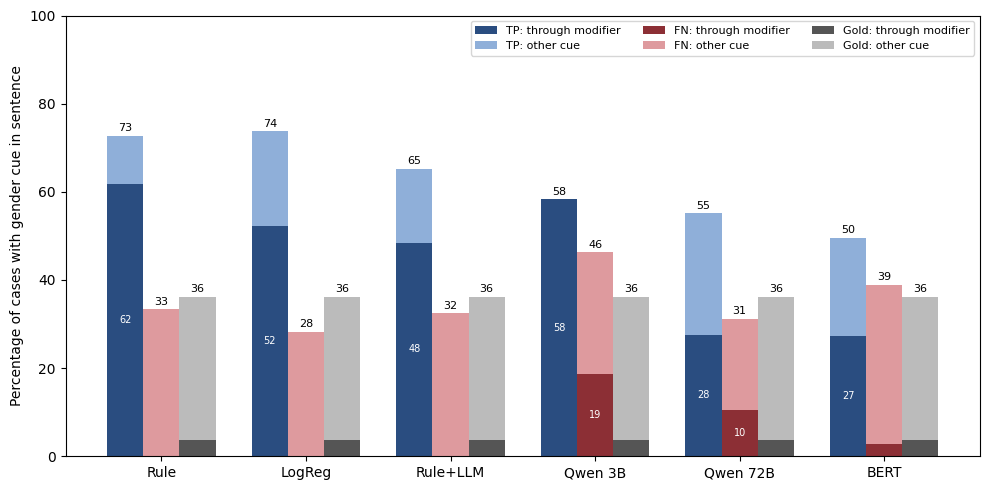

In [103]:
system_names = ['Rule', 'LogReg', 'Rule+LLM', 'Qwen 3B', 'Qwen 72B', 'BERT']

tp_cue = [72.7, 73.8, 65.2, 58.3, 55.1, 49.6]
tp_mod = [61.8, 52.3, 48.5, 58.3, 27.6, 27.3]

fn_cue = [33.3, 28.3, 32.5, 46.3, 31.2, 38.9]
fn_mod = [0.0, 0.0, 0.0, 18.7, 10.4, 2.8]

gold_cue = 36.2
gold_mod = 3.7

x = np.arange(len(system_names))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))

lexical_cue_type(x - width, tp_cue, tp_mod, '#2A4D80', '#8FAFD9', 'TP:')
lexical_cue_type(x, fn_cue, fn_mod, '#8C2F35', '#DE9A9E', 'FN:')

gold_cue_list = []
gold_mod_list = []
for i in range(len(system_names)):
    gold_cue_list.append(gold_cue)
    gold_mod_list.append(gold_mod)
lexical_cue_type(x + width, gold_cue_list, gold_mod_list, '#555555', '#BBBBBB', 'Gold:')

ax.set_xticks(x)
ax.set_xticklabels(system_names)
ax.set_ylabel('Percentage of cases with gender cue in sentence')
ax.set_ylim(0, 100)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:6], labels[:6], loc='upper right', fontsize=8, ncol=3)

plt.tight_layout()
#plt.savefig('../results/cue_conditions_gendered.pdf', bbox_inches='tight')
plt.show()

In [104]:
def all_label_cue_breakdown(features):
    categories = {
        'no cue': {'total': 0, 'with_modifier': 0},
        'one gender cue': {'total': 0, 'with_modifier': 0},
        'both gender cues': {'total': 0, 'with_modifier': 0},
    }

    for f in features:
        if f['label'] != 'unambiguous_all':
            continue

        has_fem = f['closest_fem_path'] != 'none'
        has_masc = f['closest_masc_path'] != 'none'

        if has_fem and has_masc:
            category = 'both gender cues'
        elif has_fem or has_masc:
            category = 'one gender cue'
        else:
            category = 'no cue'

        categories[category]['total'] += 1

        if f['modifier_gender'] != 'none':
            categories[category]['with_modifier'] += 1

    grand_total = 0
    for name in categories:
        grand_total += categories[name]['total']

    print('unambiguous_all, n =', grand_total)
    for name in categories:
        total = categories[name]['total']
        with_mod = categories[name]['with_modifier']
        if grand_total > 0:
            pct = round(total / grand_total * 100, 1)
        else:
            pct = 0
        print(name + ':', total, '(' + str(pct) + '%)',
              '- of which via modifier:', with_mod)

    return categories

all_label_cue_breakdown(features)

unambiguous_all, n = 32
no cue: 21 (65.6%) - of which via modifier: 0
one gender cue: 7 (21.9%) - of which via modifier: 0
both gender cues: 4 (12.5%) - of which via modifier: 0


{'no cue': {'total': 21, 'with_modifier': 0},
 'one gender cue': {'total': 7, 'with_modifier': 0},
 'both gender cues': {'total': 4, 'with_modifier': 0}}

In [105]:
def all_cue_category(f):
    has_fem = f['closest_fem_path'] != 'none'
    has_masc = f['closest_masc_path'] != 'none'
    if has_fem and has_masc:
        return 'both gender cues'
    elif has_fem or has_masc:
        return 'one gender cue'
    else:
        return 'no cue'


def all_label_recognition_table(features, results, system_names):
    category_names = ['both gender cues', 'one gender cue', 'no cue']

    gold_counts = {}
    for name in category_names:
        gold_counts[name] = 0

    for f in features:
        if f['label'] != 'unambiguous_all':
            continue
        category = all_cue_category(f)
        gold_counts[category] += 1

    recognised = {}
    for system_name in system_names:
        recognised[system_name] = {}
        for name in category_names:
            recognised[system_name][name] = 0

        tp_list = results[system_name]['unambiguous_all']['tp']
        for f in tp_list:
            category = all_cue_category(f)
            recognised[system_name][category] += 1

    header = 'category' + '\t' + 'gold'
    for system_name in system_names:
        header = header + '\t' + system_name
    print(header)

    for name in category_names:
        row = name + '\t' + str(gold_counts[name])
        for system_name in system_names:
            row = row + '\t' + str(recognised[system_name][name])
        print(row)


system_names = ['rule', 'logreg', 'rule_llm', 'qwen3b', 'qwen72b', 'bert']
all_label_recognition_table(features, results, system_names)

category	gold	rule	logreg	rule_llm	qwen3b	qwen72b	bert
both gender cues	4	0	0	0	0	0	0
one gender cue	7	0	0	0	0	0	0
no cue	21	0	0	0	1	1	1


In [106]:
#for dct in rule_cue:
#    if dct['cue_type'] == 'pronoun' and dct['predicted'] != dct['label']:
#        print(dct['s2'])
#        print()

In [107]:
#for dct in rule_cue:
#    if dct['cue_type'] == 'title' and dct['predicted'] == dct['label']:
#        print(dct['s2'])
#        print()

In [108]:
systems = {
    'qwen72b_cue': qwen72b_cue,
    'qwen3b_cue': qwen3b_cue,
    'logreg_cue': logreg_cue,
    'rule_cue': rule_cue,
    'bert_cue': bert_cue,
}

for system_name, system_data in systems.items():
    role_count = 0
    name_count = 0
    for dct in system_data:
        if dct['cue_type'] == 'title' and dct['predicted'] != dct['label']:
            if 'President' in dct['s2']:
                role_count += 1
            else:
                name_count += 1
    total = role_count + name_count
    print(system_name)
    print('  role (contains "President"):', role_count)
    print('  name (all other cases):     ', name_count)
    print('  total errors:               ', total)
    print()

qwen72b_cue
  role (contains "President"): 0
  name (all other cases):      2
  total errors:                2

qwen3b_cue
  role (contains "President"): 12
  name (all other cases):      28
  total errors:                40

logreg_cue
  role (contains "President"): 25
  name (all other cases):      8
  total errors:                33

rule_cue
  role (contains "President"): 23
  name (all other cases):      10
  total errors:                33

bert_cue
  role (contains "President"): 0
  name (all other cases):      0
  total errors:                0



In [109]:
systems = {
    'qwen72b_cue': qwen72b_cue,
    'qwen3b_cue': qwen3b_cue,
    'logreg_cue': logreg_cue,
    'rule_cue': rule_cue,
    'bert_cue': bert_cue,
}

for system_name, system_data in systems.items():
    totals = {}
    corrects = {}
    for dct in system_data:
        if dct['cue_type'] == 'lexical':
            noun = dct['seed']
            if noun not in totals:
                totals[noun] = 0
                corrects[noun] = 0
            totals[noun] += 1
            if dct['predicted'] == dct['label']:
                corrects[noun] += 1

    #print(system_name)
    for noun in sorted(totals):
        total = totals[noun]
        correct = corrects[noun]
        pct = 100 * correct / total
        #print('  {:<20} {:>4}/{:<4} {:6.1f}%'.format(noun, correct, total, pct))
    #print()

In [110]:
systems = {'qwen72b_cue': qwen72b_cue,
    'qwen3b_cue': qwen3b_cue,
    'logreg_cue': logreg_cue,
    'rule_cue': rule_cue,
    'bert_cue': bert_cue}

for system_name, system_data in systems.items():
    #count totals and correct per target noun
    totals = {}
    corrects = {}
    for dct in system_data:
        if dct['cue_type'] == 'lexical':
            noun = dct['seed']
            if noun not in totals:
                totals[noun] = 0
                corrects[noun] = 0
            totals[noun] += 1
            if dct['predicted'] == dct['label']:
                corrects[noun] += 1

    # find seeds that were sometimes right, sometimes wrong
    mixed_seeds = []
    for noun in totals:
        if corrects[noun] > 0 and corrects[noun] < totals[noun]:
            mixed_seeds.append(noun)

    # second pass: print the misclassified sentences for those seeds
#    print('=' * 150)
#    print(system_name)
#    print()
#    for noun in sorted(mixed_seeds):
#        print()
#        print(noun, '({}/{})'.format(corrects[noun], totals[noun]))
#        for dct in system_data:
#            if dct['cue_type'] == 'lexical' and dct['seed'] == noun:
#                if dct['predicted'] != dct['label']:
#                    print('  predicted:', dct['predicted'], '| label:', dct['label'])
#                    print(' ', dct['s2'])
#                    print()
#    print()

In [111]:
def report_false_negatives_no_cue(system_dicts, system_names):
    female_values = []
    male_values = []
    all_values = []

    for result_dict in system_dicts:
        female = 0
        male = 0
        unamb_all = 0
        total = 0
        for dct in result_dict:
            if dct['cue_type'] == 'no_cue' and dct['label'] == 'ambiguous':
                total += 1
                if dct['predicted'] == 'unambiguous_female':
                    female += 1
                elif dct['predicted'] == 'unambiguous_male':
                    male += 1
                elif dct['predicted'] == 'unambiguous_all':
                    unamb_all += 1
        female_values.append(female / total * 100)
        male_values.append(male / total * 100)
        all_values.append(unamb_all / total * 100)

    #stacking bottom to top: female --> male --> all
    male_bottom = female_values
    all_bottom = []
    for i in range(len(system_names)):
        all_bottom.append(female_values[i] + male_values[i])

    fig, ax = plt.subplots()
    ax.bar(system_names, female_values, color = '#8172B3', label = 'unambiguous_female')
    ax.bar(system_names, male_values, bottom = male_bottom, color = '#E69F00', label = 'unambiguous_male')
    ax.bar(system_names, all_values, bottom = all_bottom, color = '#009E73', label = 'unambiguous_all')
    ax.set_ylabel('% of ambiguous instances without a gender cue')
    ax.set_xlabel('system')
    ax.legend()
    plt.xticks(rotation = 45, ha = 'right')
    #plt.savefig('../../confusion-matrices/no_cue/false_negatives_no_cue_all_systems.pdf', bbox_inches='tight')
    plt.show()

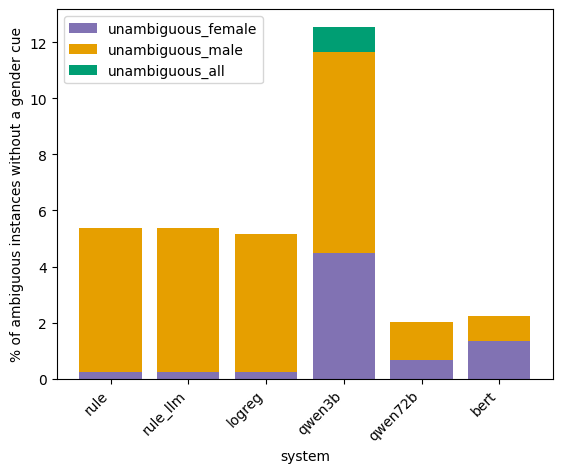

In [112]:
system_dicts = [rule_cue, rule_llm_cue, logreg_cue, qwen3b_cue, qwen72b_cue, bert_cue]
system_names = ['rule', 'rule_llm', 'logreg', 'qwen3b', 'qwen72b', 'bert']

report_false_negatives_no_cue(system_dicts, system_names)

In [113]:
def report_false_negatives_stereotype_table(system_dicts, system_names):
    rows = []
    for result_dict, name in zip(system_dicts, system_names):
        counts_f = {'female': 0, 'male': 0, 'all': 0, 'ambiguous': 0, 'total': 0}
        counts_m = {'female': 0, 'male': 0, 'all': 0, 'ambiguous': 0, 'total': 0}
        for dct in result_dict:
            if dct['cue_type'] == 'no_cue':
                continue
            if dct['label'] == 'ambiguous':
                continue
            if dct['label'] == dct['predicted']:
                continue
            if dct['stereotype'] == 'female_stereotyped':
                counts = counts_f
            elif dct['stereotype'] == 'male_stereotyped':
                counts = counts_m
            else:
                continue
            counts['total'] += 1
            if dct['predicted'] == 'unambiguous_female':
                counts['female'] += 1
            elif dct['predicted'] == 'unambiguous_male':
                counts['male'] += 1
            elif dct['predicted'] == 'unambiguous_all':
                counts['all'] += 1
            elif dct['predicted'] == 'ambiguous':
                counts['ambiguous'] += 1
        for stereo_label, counts in [('female_stereo', counts_f), ('male_stereo', counts_m)]:
            if counts['total'] != 0:
                pct_female = counts['female'] / counts['total'] * 100
                pct_male = counts['male'] / counts['total'] * 100
                pct_all = counts['all'] / counts['total'] * 100
                pct_ambiguous = counts['ambiguous'] / counts['total'] * 100
            else:
                pct_female = 0
                pct_male = 0
                pct_all = 0
                pct_ambiguous = 0
            rows.append({
                'system': name,
                'stereotype': stereo_label,
                'unambiguous_female': pct_female,
                'unambiguous_male': pct_male,
                'unambiguous_all': pct_all,
                'ambiguous': pct_ambiguous,
                'total': counts['total'],
            })
    # print a readable table
    header = ['system', 'stereotype', 'unamb_female', 'unamb_male', 'unamb_all', 'ambiguous', 'n']
    print('{:<16}{:<14}{:>14}{:>12}{:>11}{:>11}{:>6}'.format(*header))
    for row in rows:
        print('{:<16}{:<14}{:>13.1f}%{:>11.1f}%{:>10.1f}%{:>10.1f}%{:>6}'.format(row['system'],
            row['stereotype'],
            row['unambiguous_female'],
            row['unambiguous_male'],
            row['unambiguous_all'],
            row['ambiguous'],
            row['total']))
    return rows

In [114]:
#for dct in rule_cue:
#    if dct['cue_type'] == 'title' and dct['predicted'] == dct['label']:
#        print(dct['s2'])
#        print()

In [115]:
def print_no_cue_cases(result_dict, system = 'rule', only_errors = True):
    print(system)

    cases_by_seed = {}
    for dct in result_dict:
        if dct['cue_type'] != 'no_cue':
            continue
        if dct['label'] != 'ambiguous':
            continue
        if only_errors and dct['predicted'] == 'ambiguous':
            continue

        seed = dct['seed']
        if seed not in cases_by_seed:
            cases_by_seed[seed] = []
        cases_by_seed[seed].append(dct)

    sorted_seeds = sorted(cases_by_seed.keys(), key = lambda s: len(cases_by_seed[s]), reverse = True)

    total = 0
    for seed in sorted_seeds:
        cases = cases_by_seed[seed]
        total += len(cases)
        print()
        print(f'{seed} ({len(cases)} misclassifications)')
        for dct in cases:
            print(f'  dataset: {dct["dataset_type"]}  ->  predicted: {dct["predicted"]}')
            if 's2' in dct:
                print(dct['s2'])

    print(f'total: {total} cases, {len(sorted_seeds)} distinct target nouns')

In [116]:
def print_stereotype_cases(result_dict, system = 'rule', only_errors = True):
    print(system)

    # collect cases per target noun
    cases_by_seed = {}
    for dct in result_dict:
        if dct['cue_type'] == 'no_cue':
            continue
        if dct['label'] == 'ambiguous':
            continue
        if dct['stereotype'] not in ['female_stereotyped', 'male_stereotyped']:
            continue
        if only_errors and dct['predicted'] == dct['label']:
            continue

        seed = dct['seed']
        if seed not in cases_by_seed:
            cases_by_seed[seed] = []
        cases_by_seed[seed].append(dct)

    # sort nouns by number of misclassifications, most frequent first
    sorted_seeds = sorted(cases_by_seed.keys(), key = lambda s: len(cases_by_seed[s]), reverse = True)

    total = 0
    for seed in sorted_seeds:
        cases = cases_by_seed[seed]
        total += len(cases)
        print()
        print(f'{seed} ({len(cases)} misclassifications)')
        for dct in cases:
            print(f'  stereotype: {dct["stereotype"]}  ->  predicted: {dct["predicted"]}')
            if 's2' in dct:
                print(dct['s2'])
            
    print(f'total: {total} cases, {len(sorted_seeds)} distinct target nouns')

In [117]:
#print_no_cue_cases(rule_cue, system = 'rule')
#print_no_cue_cases(rule_llm_cue, system = 'rule_llm')
#print_no_cue_cases(qwen3b_cue, system = 'qwen3b')
#print_no_cue_cases(qwen72b_cue, system = 'qwen72b')
#print_no_cue_cases(bert_cue, system = 'bert')
#print_no_cue_cases(logreg_cue, system = 'logreg')

In [118]:
#print_stereotype_cases(rule_cue, system = 'rule')
#print_stereotype_cases(rule_llm_cue, system = 'rule_llm')
#print_stereotype_cases(qwen3b_cue, system = 'qwen3b')
#print_stereotype_cases(qwen72b_cue, system = 'qwen72b')
#print_stereotype_cases(bert_cue, system = 'bert')
#print_stereotype_cases(logreg_cue, system = 'logreg')

In [119]:
#system_dicts = [rule_cue, rule_llm_cue, qwen3b_cue, qwen72b_cue, bert_cue, logreg_cue]
#system_names = ['rule', 'rule_llm', 'qwen3b', 'qwen72b', 'bert', 'logreg']
#report_false_negatives_stereotype_table(system_dicts, system_names)